# Stochastic Optimization Scheduler Comparison

Single notebook orchestrating all experiment versions (V0–V5).

**Objective**: Compare learning rate schedulers (None, Exponential Decay, Cosine Annealing, Cyclic LR, One-Cycle) across optimizers (SGD, Adam) on convex (logistic regression) and non-convex (MLP on MNIST) problems.

**Metrics**: Convergence speed (EtT), Area Under Loss (AUL), empirical convergence rate (ρ̂), stability (RV/CV, SI), Robbins-Monro compliance.

## 1. Imports

In [2]:
%load_ext autoreload
%autoreload 2

In [9]:
import time
from pathlib import Path
import pickle

import pandas as pd
import torch

from stoc_opt_scheduler_comparison.config import load_config
from stoc_opt_scheduler_comparison.data_load import get_dataloaders
from stoc_opt_scheduler_comparison.models import create_model
from stoc_opt_scheduler_comparison.training import get_optimizer, get_scheduler, train_loop
from stoc_opt_scheduler_comparison.tracking import MLflowLogger, load_results_from_mlflow
from stoc_opt_scheduler_comparison.training.lstar import (
    compute_convex_L_star,
    compute_nonconvex_L_star,
)
from stoc_opt_scheduler_comparison.evaluation import (
    TrainingHistory,
    compute_convergence_metrics,
    aggregate_metrics,
    compute_L_star_global,
    compute_global_initial_loss,
    compute_all_e_target_levels,
    build_convergence_dataframe,
    CONVEX_E_TARGET_LEVELS,
    NONCONVEX_E_TARGET_LEVELS,
)
from stoc_opt_scheduler_comparison.visualization.plots import plot_all, plot_convergence_boxplot

print(f"PyTorch {torch.__version__} | Device CUDA: {torch.cuda.is_available()}")

PyTorch 2.11.0+cu130 | Device CUDA: True


## 2. Configuration

In [13]:
config = load_config("../configs/experiment_config.yaml")

print(f"Experiment: {config.experiment_name}")
print(f"Seeds: {config.seeds}")
print(f"Schedulers: {config.schedulers}")
print(f"Optimizers: {config.optimizers}")
print(f"Epochs: {config.epochs}, LR: {config.lr}, Batch: {config.batch_size}")
print(f"Experiments: {config.experiments}")

Experiment: scheduler_comparison_v3
Seeds: (6, 22, 84, 165, 405, 440, 492, 561, 910, 947)
Schedulers: ('none', 'cosine', 'exponential', 'cyclic', 'one-cycle')
Optimizers: ('sgd', 'adam')
Epochs: 100, LR: {'sgd': 0.01, 'adam': 0.001}, Batch: 128
Experiments: {'convex': ExperimentDef(model='logistic', dataset='breast_cancer', batch_size=128, epochs=50), 'non-convex': ExperimentDef(model='mlp', dataset='mnist', batch_size=128, epochs=100)}


In [14]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Output directories
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures saved to: {figures_dir.absolute()}")

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Results saved to: {results_dir.absolute()}")

Using device: cuda
Figures saved to: /home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/notebooks/../reports/figures
Results saved to: /home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/notebooks/../results


## 3. Experiment Matrix

Each experiment is defined by: `(problem_type, scheduler, optimizer, seed)`.

The config specifies which model and dataset to use for each problem type.

In [15]:
def build_experiment_matrix(config):
    """Build list of (problem_type, scheduler, optimizer, seed) tuples."""
    matrix = []
    for problem_type, exp_def in config.experiments.items():
        for scheduler in config.schedulers:
            for optimizer in config.optimizers:
                for seed in config.seeds:
                    matrix.append((problem_type, exp_def, scheduler, optimizer, seed))
    return matrix

experiment_matrix = build_experiment_matrix(config)
print(f"Total experiments: {len(experiment_matrix)}")
print(f"  Convex: {len([e for e in experiment_matrix if e[0] == 'convex'])}")
print(f"  Non-convex: {len([e for e in experiment_matrix if e[0] == 'non-convex'])}")

Total experiments: 200
  Convex: 100
  Non-convex: 100


## 4. Run All Experiments

For each configuration:
1. Load data (with seed for reproducibility)
2. Create model
3. Create optimizer + scheduler
4. Train and collect history
5. Log to MLflow

In [ ]:
def run_single_experiment(problem_type, exp_def, scheduler_name, optimizer_name, seed, config, mlflow_logger):
    """Run one experiment configuration and return (run_name, history, test_metrics)."""
    run_name = f"{problem_type}_{scheduler_name}_{optimizer_name}_{seed}"

    # Per-experiment epoch count (falls back to global config)
    epochs = exp_def.epochs or config.epochs


    # batch_size per-experiment overrides global config
    batch_size = exp_def.batch_size
    
    # Load data
    dataloaders = get_dataloaders(
        dataset_name=exp_def.dataset,
        batch_size=batch_size,
        seed=seed,
        test_size=config.test_size,
    )
    
    # Create model
    model = create_model(
        name=exp_def.model,
        input_dim=dataloaders["n_features"],
        output_dim=dataloaders["n_classes"],
    )
    
    # Create optimizer + scheduler
    lr = config.lr.get(optimizer_name, 0.001) if isinstance(config.lr, dict) else config.lr
    optimizer = get_optimizer(model, name=optimizer_name, lr=lr)
    sched_params = config.scheduler_params.get(scheduler_name, {})

    # ExponentialLR needs gamma calculated based on target drop and epochs
    if scheduler_name == "exponential":
        target_drop = 100.0 # Target drop factor (100x reduction of initial lr)
        gamma = (1.0 / target_drop) ** (1.0 / epochs)
        sched_params = {**sched_params, "gamma": gamma}

    # CosineAnnealingLR needs T_max = epochs
    if scheduler_name == "cosine":
        sched_params = {**sched_params, "T_max": epochs}
    
    # OneCycleLR needs computed parameter from dataloader length and epochs
    if scheduler_name == "one-cycle":
        sched_params = {**sched_params, "epochs": epochs, "steps_per_epoch": len(dataloaders["train"])}
    
    # CyclicLR needs step_size_up = 2x dataloader length (Smith's recommendation from original paper)
    if scheduler_name == "cyclic":
        sched_params = {**sched_params, "base_lr": lr, "step_size_up": 2 * len(dataloaders["train"])}

    scheduler = get_scheduler(optimizer, name=scheduler_name, **sched_params)
    
    # Train
    history = train_loop(
        model=model,
        train_loader=dataloaders["train"],
        test_loader=dataloaders["test"],
        optimizer=optimizer,
        scheduler=scheduler,
        scheduler_name=scheduler_name,
        epochs=epochs,
        device=device,
        verbose=epochs,  # Suppress per-epoch output during batch runs
    )
    
    # Log to MLflow
    with mlflow_logger.child_run(run_name):
        mlflow_logger.log_params({
            "problem_type": problem_type,
            "model": exp_def.model,
            "dataset": exp_def.dataset,
            "optimizer": optimizer_name,
            "scheduler": scheduler_name,
            "seed": seed,
            "lr": config.lr,
            "epochs": epochs,
            "batch_size": batch_size,
        })
        mlflow_logger.log_history(history)
    
    # Convert lists to numpy arrays for efficient post-processing
    history.to_arrays()

    return run_name, history


def run_all_experiments(config, experiment_matrix):
    """Run all experiments and collect results."""
    results = {"convex": {}, "non-convex": {}}
    mlflow_logger = MLflowLogger(config.experiment_name, tracking_uri="../mlruns")
    
    total = len(experiment_matrix)
    start_time = time.time()
    
    for i, (problem_type, exp_def, scheduler, optimizer, seed) in enumerate(experiment_matrix, 1):
        run_name, history = run_single_experiment(
            problem_type, exp_def, scheduler, optimizer, seed, config, mlflow_logger
        )
        
        results[problem_type][run_name] = history
        
        elapsed = time.time() - start_time
        eta = elapsed / i * (total - i) if i > 0 else 0
        print(f"[{i}/{total}] {run_name}: test_acc={history.test_metrics.get('accuracy', 0):.4f} | ETA: {eta/60:.1f}min")
    
    total_time = time.time() - start_time
    print(f"\nAll experiments complete in {total_time/60:.1f} minutes")
    return results

In [24]:
# Execute all experiments
results = run_all_experiments(config, experiment_matrix)

/home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/.venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/05 03:15:03 INFO mlflow.tracking.fluent: Experiment with name 'scheduler_comparison_v3' does not exist. Creating a new experiment.


  Epoch 100/100: loss=0.1199, acc=0.9648, lr=0.010000
[1/200] convex_none_sgd_6: test_acc=0.9737 | ETA: 4.7min
  Epoch 100/100: loss=0.1026, acc=0.9780, lr=0.010000
[2/200] convex_none_sgd_22: test_acc=0.9386 | ETA: 2.9min
  Epoch 100/100: loss=0.0957, acc=0.9802, lr=0.010000
[3/200] convex_none_sgd_84: test_acc=0.9649 | ETA: 2.3min
  Epoch 100/100: loss=0.1237, acc=0.9626, lr=0.010000
[4/200] convex_none_sgd_165: test_acc=0.9825 | ETA: 2.0min
  Epoch 100/100: loss=0.1201, acc=0.9670, lr=0.010000
[5/200] convex_none_sgd_405: test_acc=0.9474 | ETA: 1.8min
  Epoch 100/100: loss=0.1158, acc=0.9560, lr=0.010000
[6/200] convex_none_sgd_440: test_acc=0.9737 | ETA: 1.7min
  Epoch 100/100: loss=0.1126, acc=0.9802, lr=0.010000
[7/200] convex_none_sgd_492: test_acc=0.9649 | ETA: 1.6min
  Epoch 100/100: loss=0.1242, acc=0.9582, lr=0.010000
[8/200] convex_none_sgd_561: test_acc=0.9825 | ETA: 1.5min
  Epoch 100/100: loss=0.1039, acc=0.9802, lr=0.010000
[9/200] convex_none_sgd_910: test_acc=0.9649 |

## 5. Aggregate Results & Convergence Metrics

Aggregate each run results on seed level.

Compute six convergence metrics for each run:
- **EtT**: Epochs to Threshold
- **AUL**: Area Under Loss curve
- **ρ̂**: Empirical convergence rate
- **RV/CV**: Rolling Variance / Coefficient of Variation
- **SI**: Smoothness Index
- **Robbins-Monro**: LR schedule compliance

In [7]:
# ── Compute optimal loss (L*) for each problem type ──
L_star_values = {}
L0_values = {}

# Convex L*: use L-BFGS to find analytical global minimum
print("Computing convex L* via L-BFGS...")
L_star_convex = compute_convex_L_star(test_size=config.test_size, seed=42)
print(f"  Convex L* (L-BFGS) = {L_star_convex:.6f}")

# Non-convex L*: extended training run from best config
print("\nComputing non-convex L* via extended training...")
exp_def_nc = config.experiments["non-convex"]
L_star_nonconvex = compute_nonconvex_L_star(
    results_by_problem=results["non-convex"],
    exp_def=exp_def_nc,
    scheduler_params=config.scheduler_params,
    lr_config=config.lr,
    device=device,
    extended_epochs=200,
    seed=42,
)
print(f"  Non-convex L* (extended) = {L_star_nonconvex:.6f}")

# Global initial loss (L0) for E_target computation
L0_convex = compute_global_initial_loss(results["convex"])
L0_nonconvex = compute_global_initial_loss(results["non-convex"])
print(f"\n--- Global Initial Loss (L0) ---")
print(f"  Convex L0 = {L0_convex:.6f}")
print(f"  Non-convex L0 = {L0_nonconvex:.6f}")

# ── Compute convergence metrics with proper L* values ──
convergence_results = {}
L_star_map = {"convex": L_star_convex, "non-convex": L_star_nonconvex}
L0_map = {"convex": L0_convex, "non-convex": L0_nonconvex}

for problem_type in ["convex", "non-convex"]:
    results_by_problem = results[problem_type]
    L_star_global = L_star_map[problem_type]
    L0_global = L0_map[problem_type]

    metrics_dict = compute_convergence_metrics(results, problem_type, L_star=L_star_global)
    aggregated = aggregate_metrics(metrics_dict)
    convergence_results[problem_type] = {
        "per_run": metrics_dict,
        "aggregated": aggregated,
        "L_star": L_star_global,
        "L0": L0_global,
    }
    print(f"\n=== {problem_type.upper()} ===")
    print(f"Runs analyzed: {len(metrics_dict)}")
    print(f"Configurations: {list(aggregated.keys())}")
    print(f"L* = {L_star_global:.6f}, L0 = {L0_global:.6f}")


=== CONVEX ===
Runs analyzed: 100
Configurations: ['sgd_none', 'adam_none', 'sgd_cosine', 'adam_cosine', 'sgd_exponential', 'adam_exponential', 'sgd_cyclic', 'adam_cyclic', 'sgd_one-cycle', 'adam_one-cycle']
L_star: 0.031665 | run: convex_one-cycle_adam_84

=== NON-CONVEX ===
Runs analyzed: 100
Configurations: ['sgd_none', 'adam_none', 'sgd_cosine', 'adam_cosine', 'sgd_exponential', 'adam_exponential', 'sgd_cyclic', 'adam_cyclic', 'sgd_one-cycle', 'adam_one-cycle']
L_star: 0.005546 | run: non-convex_one-cycle_sgd_910


In [ ]:
convergence_results["non-convex"]["L_star"]

'non-convex_one-cycle_sgd_910'

In [8]:
aggregated = convergence_results["convex"]["aggregated"]

for run_key, agg in aggregated.items():
    rate = agg.get("EtT_convergence_rate", float("nan"))
    n_total = agg.get("n_runs", "?")
    print(f"{run_key:<25}  EtT_convergence_rate = {rate:.1%}")

sgd_none                   EtT_convergence_rate = 60.0%
adam_none                  EtT_convergence_rate = 50.0%
sgd_cosine                 EtT_convergence_rate = 30.0%
adam_cosine                EtT_convergence_rate = 0.0%
sgd_exponential            EtT_convergence_rate = 0.0%
adam_exponential           EtT_convergence_rate = 0.0%
sgd_cyclic                 EtT_convergence_rate = 80.0%
adam_cyclic                EtT_convergence_rate = 100.0%
sgd_one-cycle              EtT_convergence_rate = 90.0%
adam_one-cycle             EtT_convergence_rate = 100.0%


## 5b. E_target (Sub-optimality Gap) Analysis

Compute epochs-to-target for multiple tolerance levels (E_target levels).
Each level defines a convergence threshold: L_target = L* + ε·(L0 − L*).

In [ ]:
e_target_results = {}

for problem_type in ["convex", "non-convex"]:
    L_star = convergence_results[problem_type]["L_star"]
    results_by_problem = results[problem_type]
    max_epochs = config.experiments[problem_type].epochs or config.epochs
    levels = CONVEX_E_TARGET_LEVELS if problem_type == "convex" else NONCONVEX_E_TARGET_LEVELS

    df_dict = compute_all_e_target_levels(
        results_by_problem, L_star, max_epochs, levels,
    )
    e_target_results[problem_type] = df_dict

    print(f"\n=== {problem_type.upper()} - E_target Analysis === ")
    for level_name, df in df_dict.items():
        n_converged = (df["Epochs_to_Target"] < max_epochs).sum()
        n_total = len(df)
        print(f"  {level_name}: {n_converged}/{n_total} converged ")
        if not df.empty:
            print(f"           L_target = {df['_L_target'].iloc[0]:.6f}")


In [9]:
# Display aggregated metrics as DataFrame
for problem_type in ["convex", "non-convex"]:
    agg = convergence_results[problem_type]["aggregated"]
    df = pd.DataFrame.from_dict(agg, orient="index")
    
    # Select key columns for display
    display_cols = [
        "optimizer", "scheduler", "n_runs",
        "EtT_mean", "EtT_std",
        "AUL_mean", "AUL_std",
        "rho_hat_mean", "rho_hat_std",
        "CV_final_mean", "CV_final_std",
        "SI_mean", "SI_std",
        "final_test_accuracy_mean", "final_test_accuracy_std",
    ]
    available_cols = [c for c in display_cols if c in df.columns]
    
    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Aggregated Metrics")
    print(f"{'='*60}")
    display(df[available_cols].round(4))


CONVEX - Aggregated Metrics


,optimizer,scheduler,n_runs,EtT_mean,EtT_std,AUL_mean,AUL_std,rho_hat_mean,rho_hat_std,CV_final_mean,CV_final_std,SI_mean,SI_std
sgd_none,sgd,none,10,52.8333,24.2172,20.1129,2.7771,0.9928,0.0007,0.0113,0.0010,0.0095,0.0057
adam_none,adam,none,10,82.0000,15.0864,27.2790,11.6070,0.9892,0.0017,0.0177,0.0034,0.0088,0.0054
sgd_cosine,sgd,cosine,10,65.0000,7.7889,24.1616,3.6629,0.9916,0.0009,0.0274,0.0022,0.0092,0.0058
adam_cosine,adam,cosine,10,NaN,NaN,31.3604,17.6982,0.9878,0.0023,0.0407,0.0110,0.0065,0.0044
sgd_exponential,sgd,exponential,10,NaN,NaN,26.0547,3.8018,0.9993,0.0001,0.0005,0.0001,0.0055,0.0037
adam_exponential,adam,exponential,10,NaN,NaN,47.0232,24.9016,0.9991,0.0002,0.0008,0.0002,0.0056,0.0034
sgd_cyclic,sgd,cyclic,10,4.5000,2.5000,8.3519,1.4322,0.9990,0.0003,0.0015,0.0004,0.0085,0.0060
adam_cyclic,adam,cyclic,10,2.1000,0.3000,7.2775,1.1507,0.9984,0.0007,0.0021,0.0004,0.0116,0.0045
sgd_one-cycle,sgd,one-cycle,10,12.7778,9.5775,7.0220,1.1274,0.9944,0.0050,0.0003,0.0001,0.0066,0.0037
adam_one-cycle,adam,one-cycle,10,8.3000,1.1000,8.4113,2.2058,0.9913,0.0082,0.0005,0.0001,0.0110,0.0051



NON-CONVEX - Aggregated Metrics


,optimizer,scheduler,n_runs,EtT_mean,EtT_std,AUL_mean,AUL_std,rho_hat_mean,rho_hat_std,CV_final_mean,CV_final_std,SI_mean,SI_std
sgd_none,sgd,none,10,45.6,1.6248,12.5813,0.1708,0.9886,0.0002,0.0310,0.0047,0.0095,0.0002
adam_none,adam,none,10,16.9,1.0440,3.7729,0.0365,NaN,NaN,0.0817,0.0221,0.0054,0.0002
sgd_cosine,sgd,cosine,10,96.2,1.6613,16.1584,0.1805,0.9904,0.0002,0.0421,0.0037,0.0093,0.0002
adam_cosine,adam,cosine,10,15.0,0.6325,2.9957,0.0519,1.0585,0.0039,0.0592,0.0131,0.0049,0.0001
sgd_exponential,sgd,exponential,10,NaN,NaN,19.3224,0.2015,NaN,NaN,0.0086,0.0019,0.0091,0.0002
adam_exponential,adam,exponential,10,12.4,0.4899,2.3883,0.0395,NaN,NaN,0.0634,0.0209,0.0046,0.0001
sgd_cyclic,sgd,cyclic,10,7.9,0.3000,3.6583,0.0698,NaN,NaN,0.0340,0.0075,0.0062,0.0001
adam_cyclic,adam,cyclic,10,NaN,NaN,147.6992,51.0901,0.9907,0.0172,0.0125,0.0161,0.0263,0.0064
sgd_one-cycle,sgd,one-cycle,10,36.5,1.2845,5.1537,0.0548,0.9155,0.0052,0.0830,0.0193,0.0065,0.0002
adam_one-cycle,adam,one-cycle,10,NaN,NaN,195.0100,5.4082,NaN,NaN,0.0007,0.0002,0.0360,0.0051


## 6. Generate All Plots

Use the `plot_all()` entry point to generate all 6 standard plots:
- Level 1: Global Comparison (loss + LR overview)
- Level 2: By Optimizer (SGD vs Adam columns) — with E_target threshold lines
- Level 3: Seed Variance (diagnostic grid) — with E_target threshold lines
- Level 4: Final Performance (train vs test comparison)
- Analytical A: Loss + LR Dual Axis (2×5 grid)
- Analytical B: Heatmap (top convergence metrics)

Plots saved to `reports/figures/`. E_target thresholds (L* + ε·(L0 − L*)) are
displayed as horizontal lines on Level 2 & 3 plots when L0 and e_target_levels are provided.

[viz] Generating all plots for: convex



Generating plots for: CONVEX
L_star = 0.0317, epsilon = 0.001


[viz] Saved: ../reports/figures/convex_level1_global_comparison.png


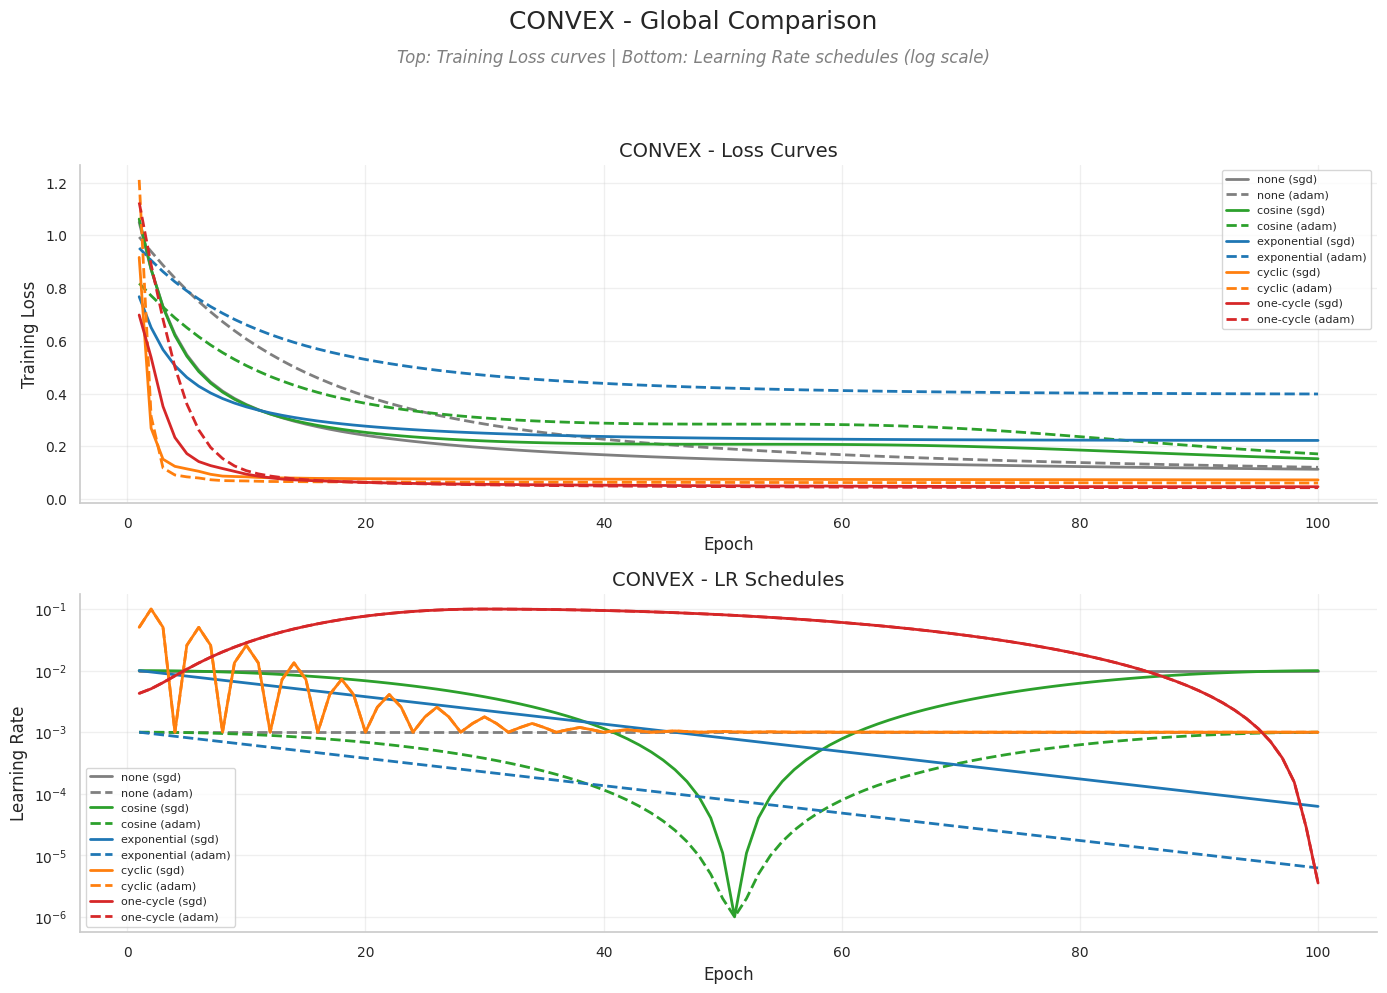

[viz] Saved: ../reports/figures/convex_level2_by_optimizer.png


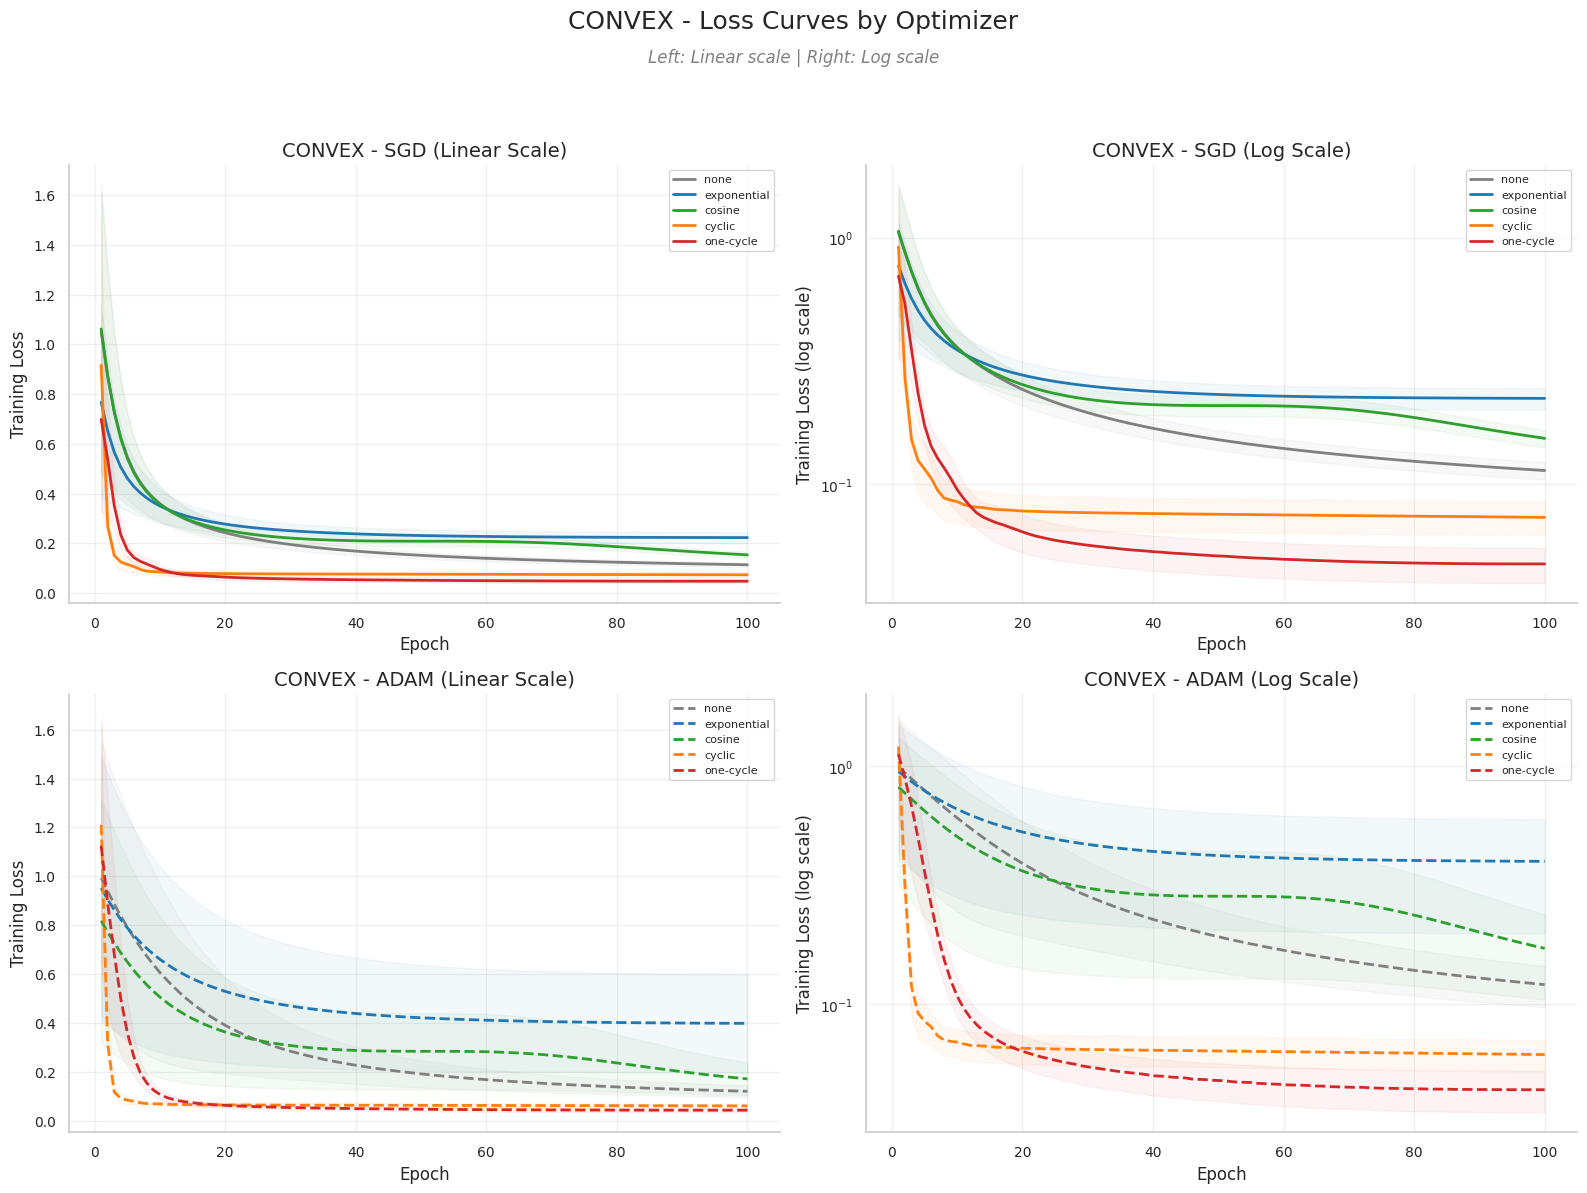

[viz] Saved: ../reports/figures/convex_level3_seed_variance.png


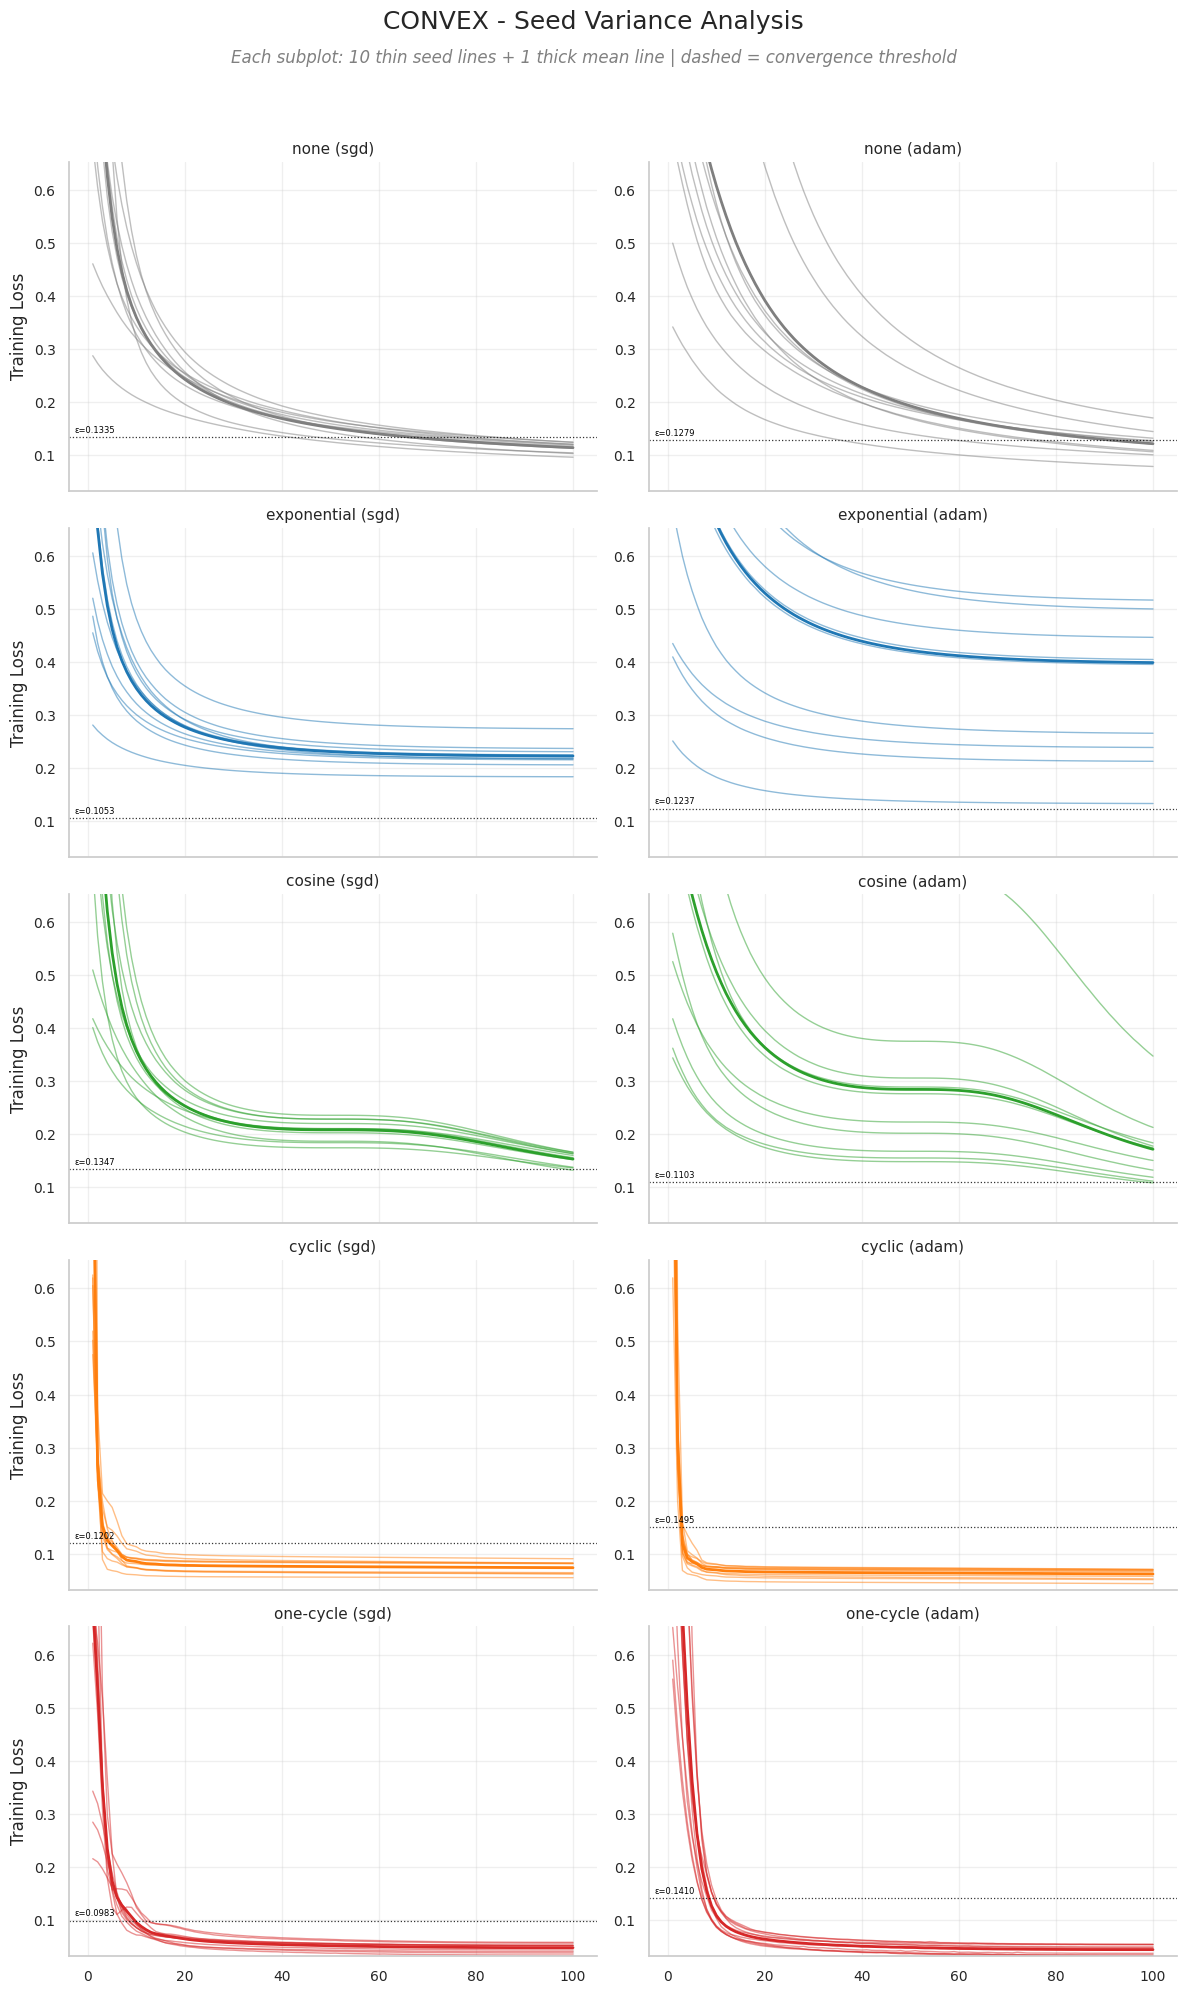

[viz] Saved: ../reports/figures/convex_level4_final_performance.png


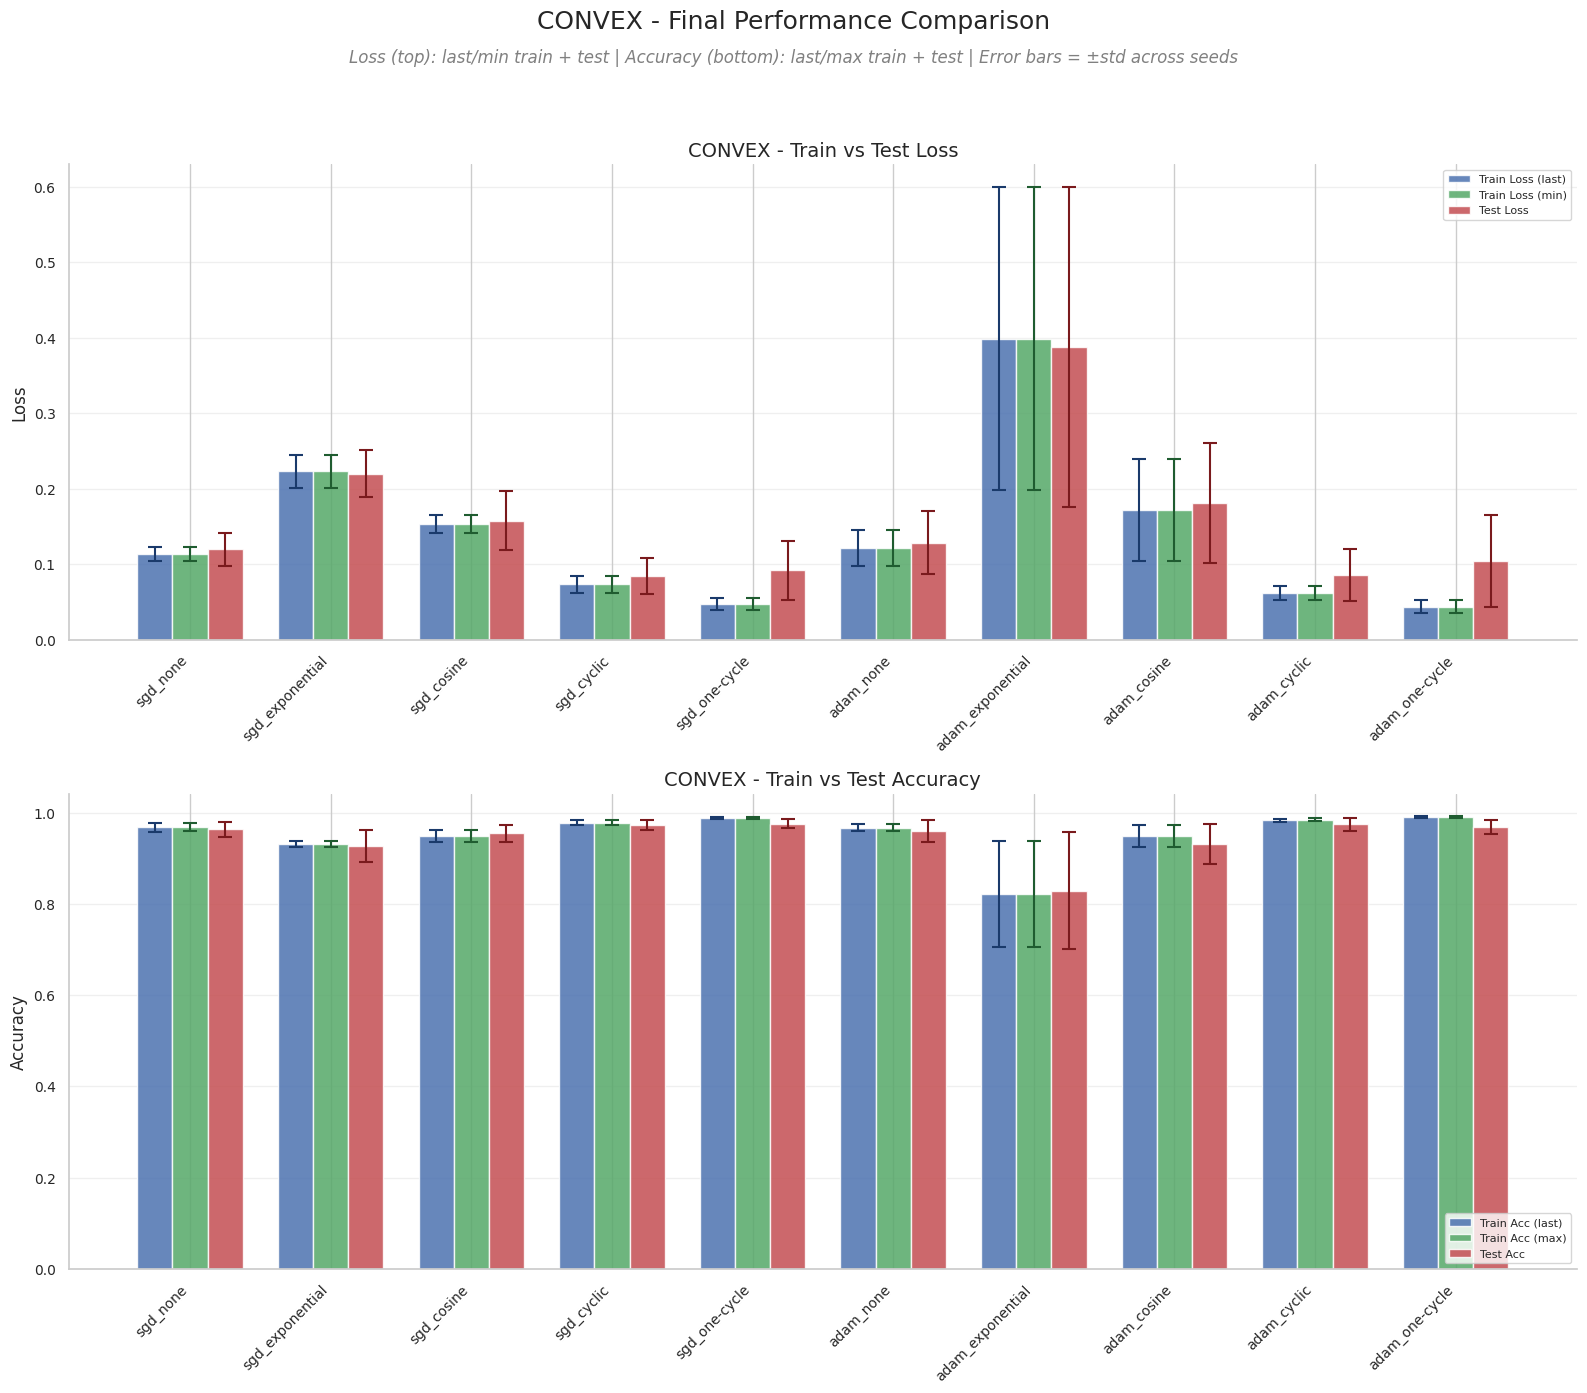

[viz] Saved: ../reports/figures/convex_analytical_a_loss_lr_dual.png


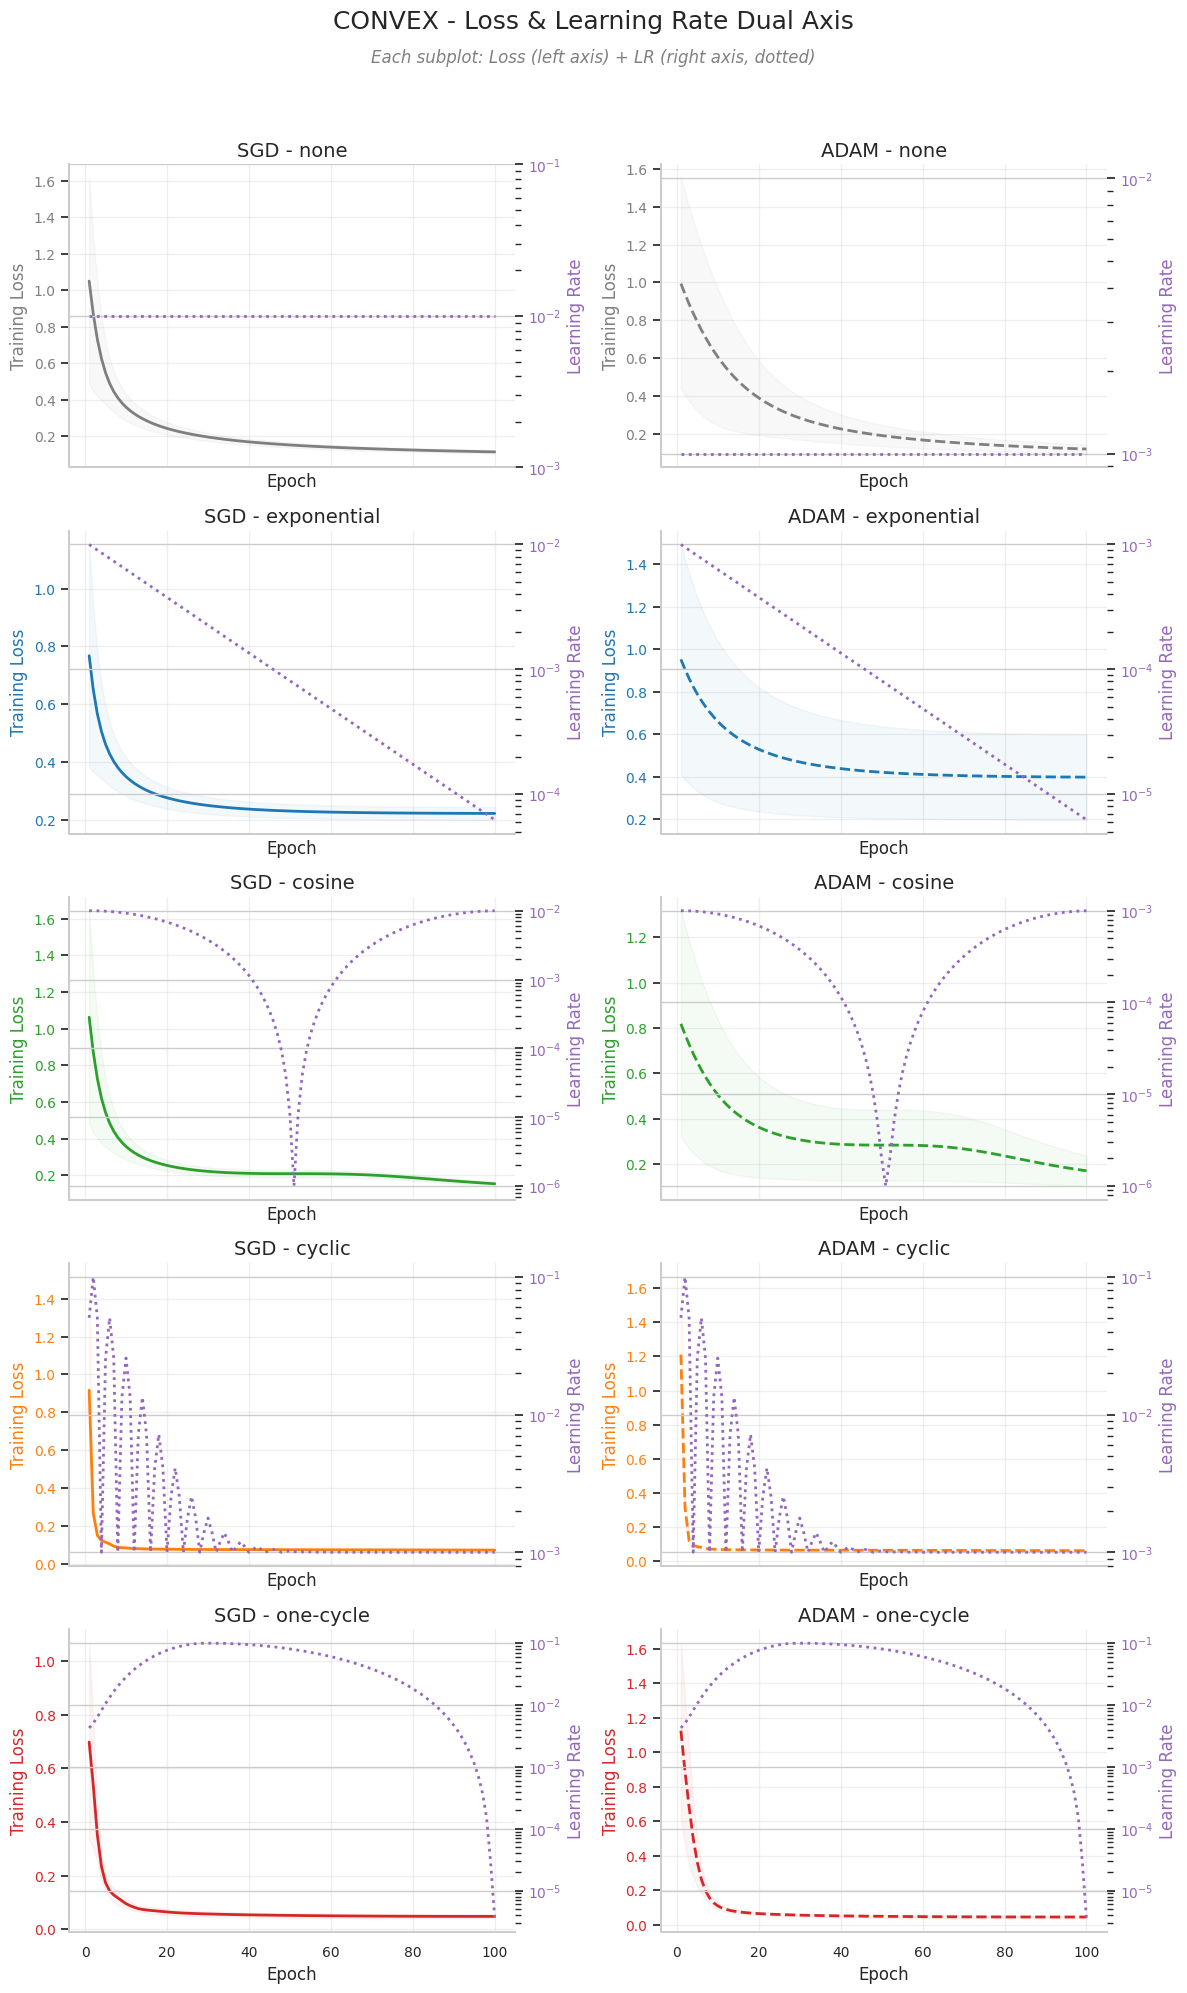

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_ett.png


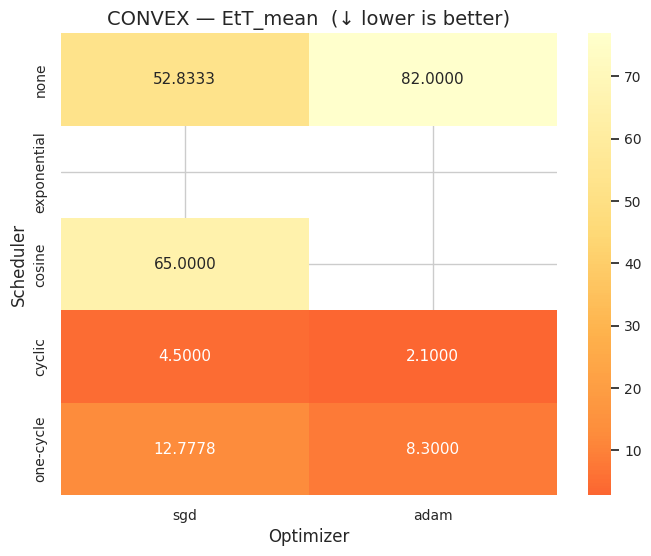

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_ett_median.png


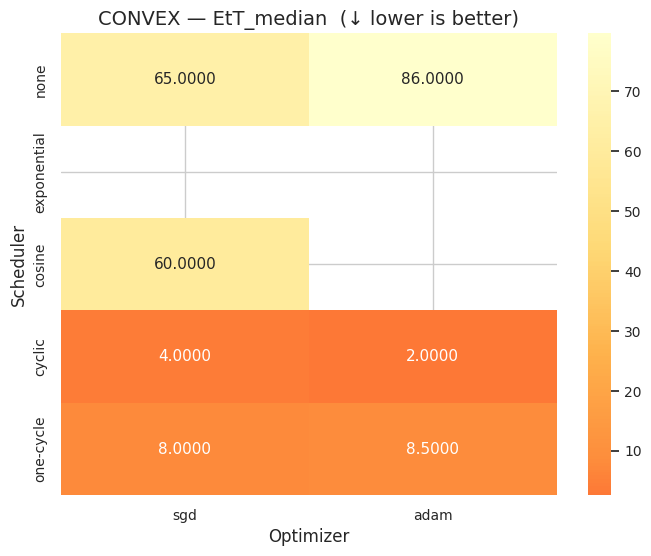

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_aul_norm.png


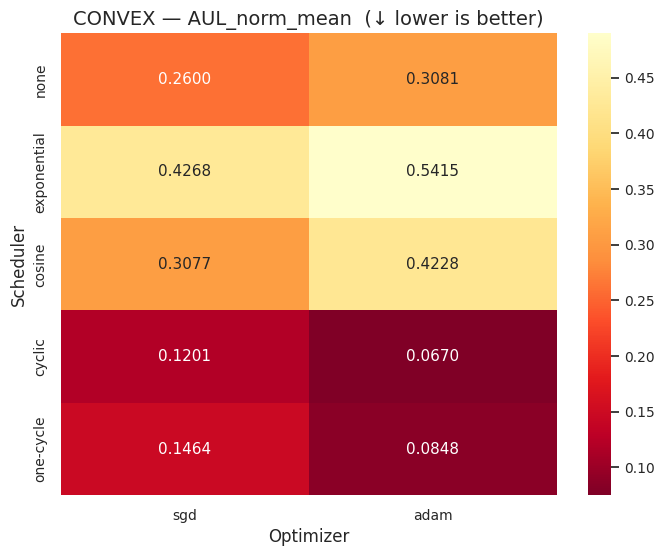

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_rho_hat.png


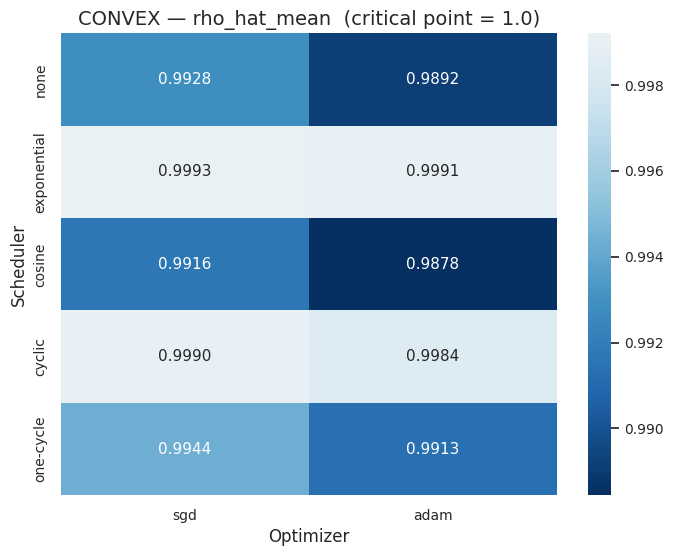

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_cv_final.png


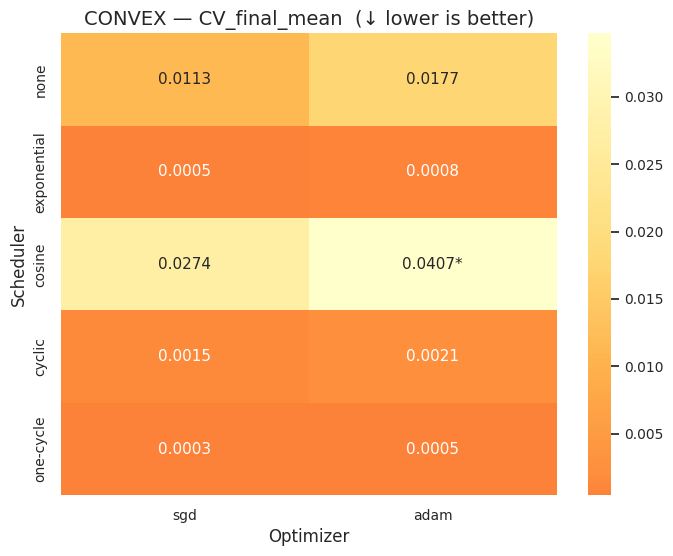

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_si.png


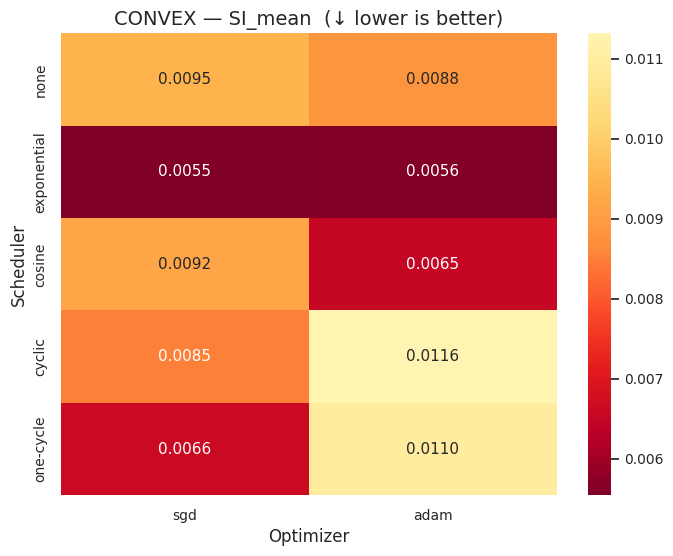

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_test_accuracy.png


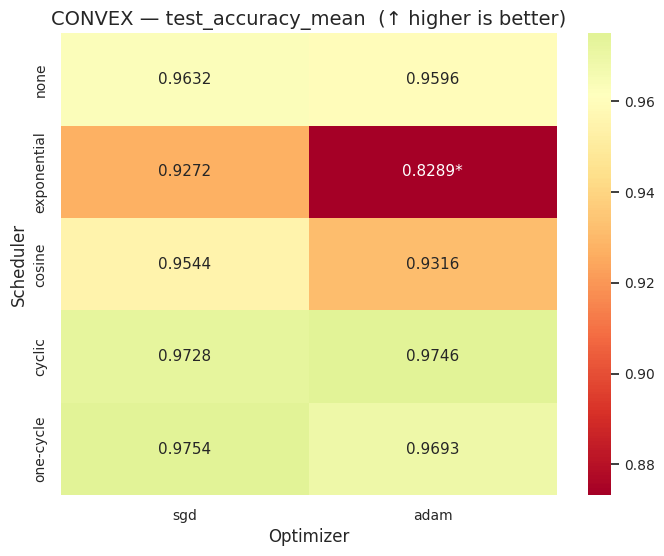

[viz] Saved: ../reports/figures/convex_analytical_b_heatmap_test_loss.png


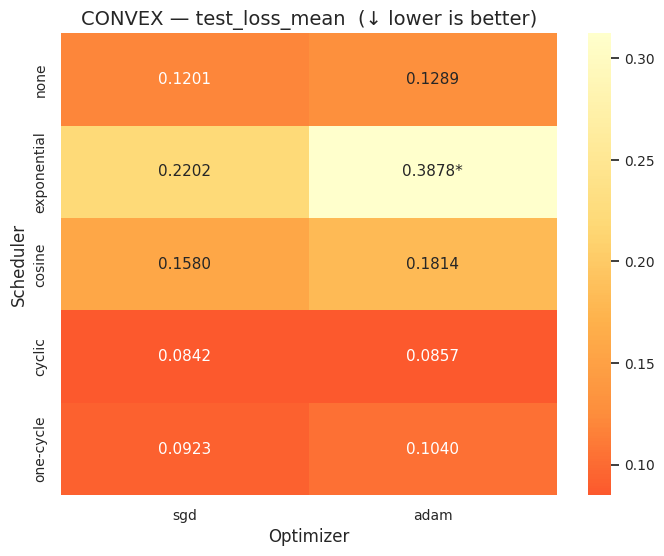

[viz] All plots saved for: convex
[viz] Generating all plots for: non-convex


Saved 6 plot files:
  - ../reports/figures/convex_level1_global_comparison.png
  - ../reports/figures/convex_level2_by_optimizer.png
  - ../reports/figures/convex_level3_seed_variance.png
  - ../reports/figures/convex_level4_final_performance.png
  - ../reports/figures/convex_analytical_a_loss_lr_dual.png
  - ['../reports/figures/convex_analytical_b_heatmap_ett.png', '../reports/figures/convex_analytical_b_heatmap_ett_median.png', '../reports/figures/convex_analytical_b_heatmap_aul_norm.png', '../reports/figures/convex_analytical_b_heatmap_rho_hat.png', '../reports/figures/convex_analytical_b_heatmap_cv_final.png', '../reports/figures/convex_analytical_b_heatmap_si.png', '../reports/figures/convex_analytical_b_heatmap_test_accuracy.png', '../reports/figures/convex_analytical_b_heatmap_test_loss.png']

Generating plots for: NON-CONVEX
L_star = 0.0055, epsilon = 0.001


[viz] Saved: ../reports/figures/non-convex_level1_global_comparison.png


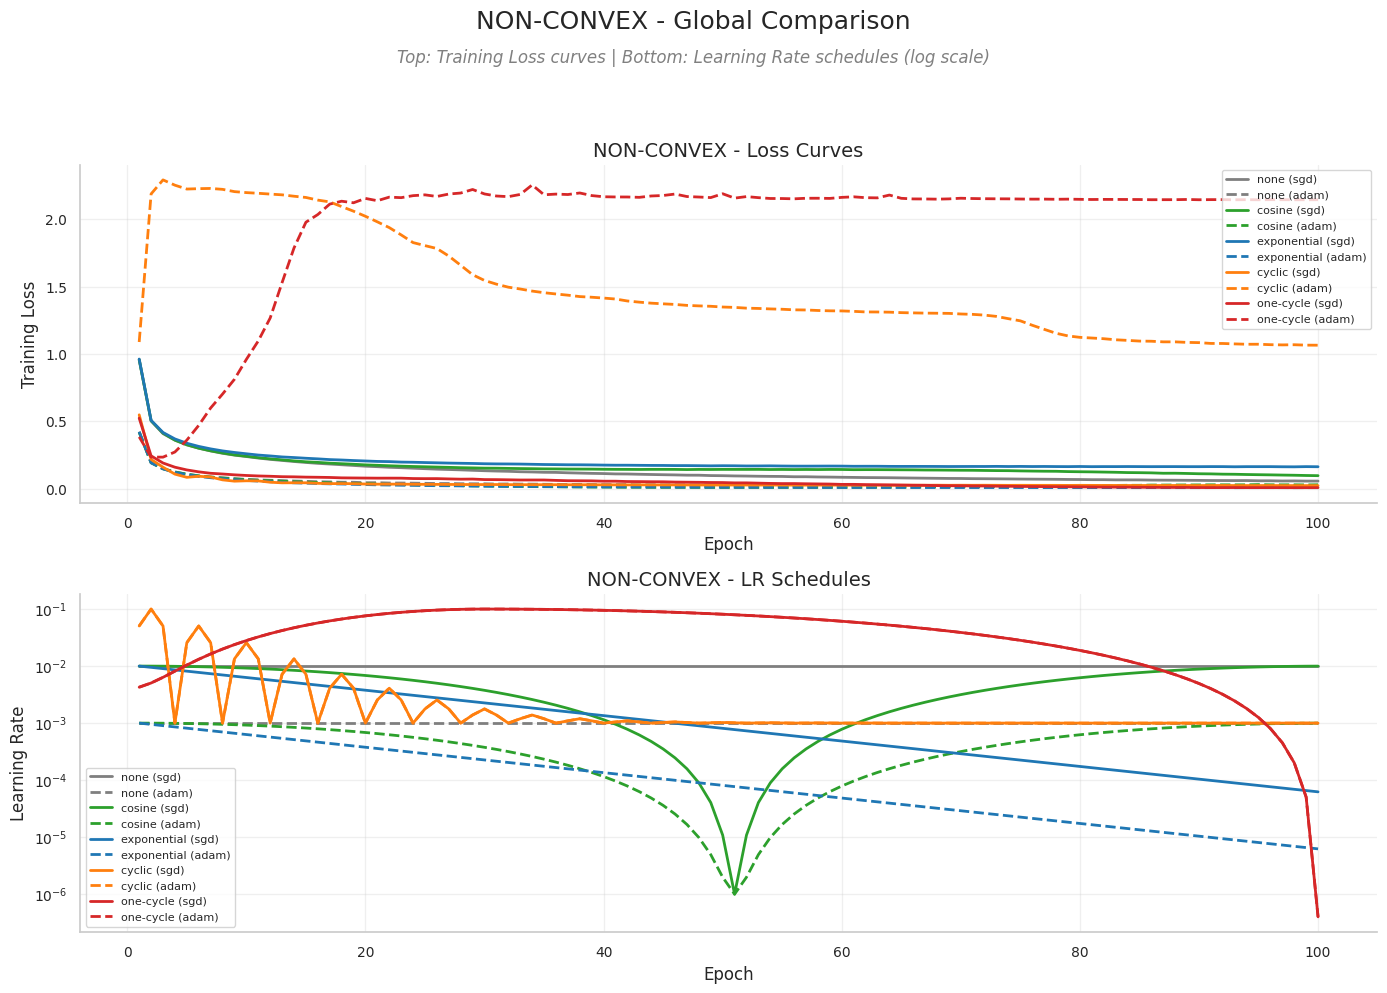

[viz] Saved: ../reports/figures/non-convex_level2_by_optimizer.png


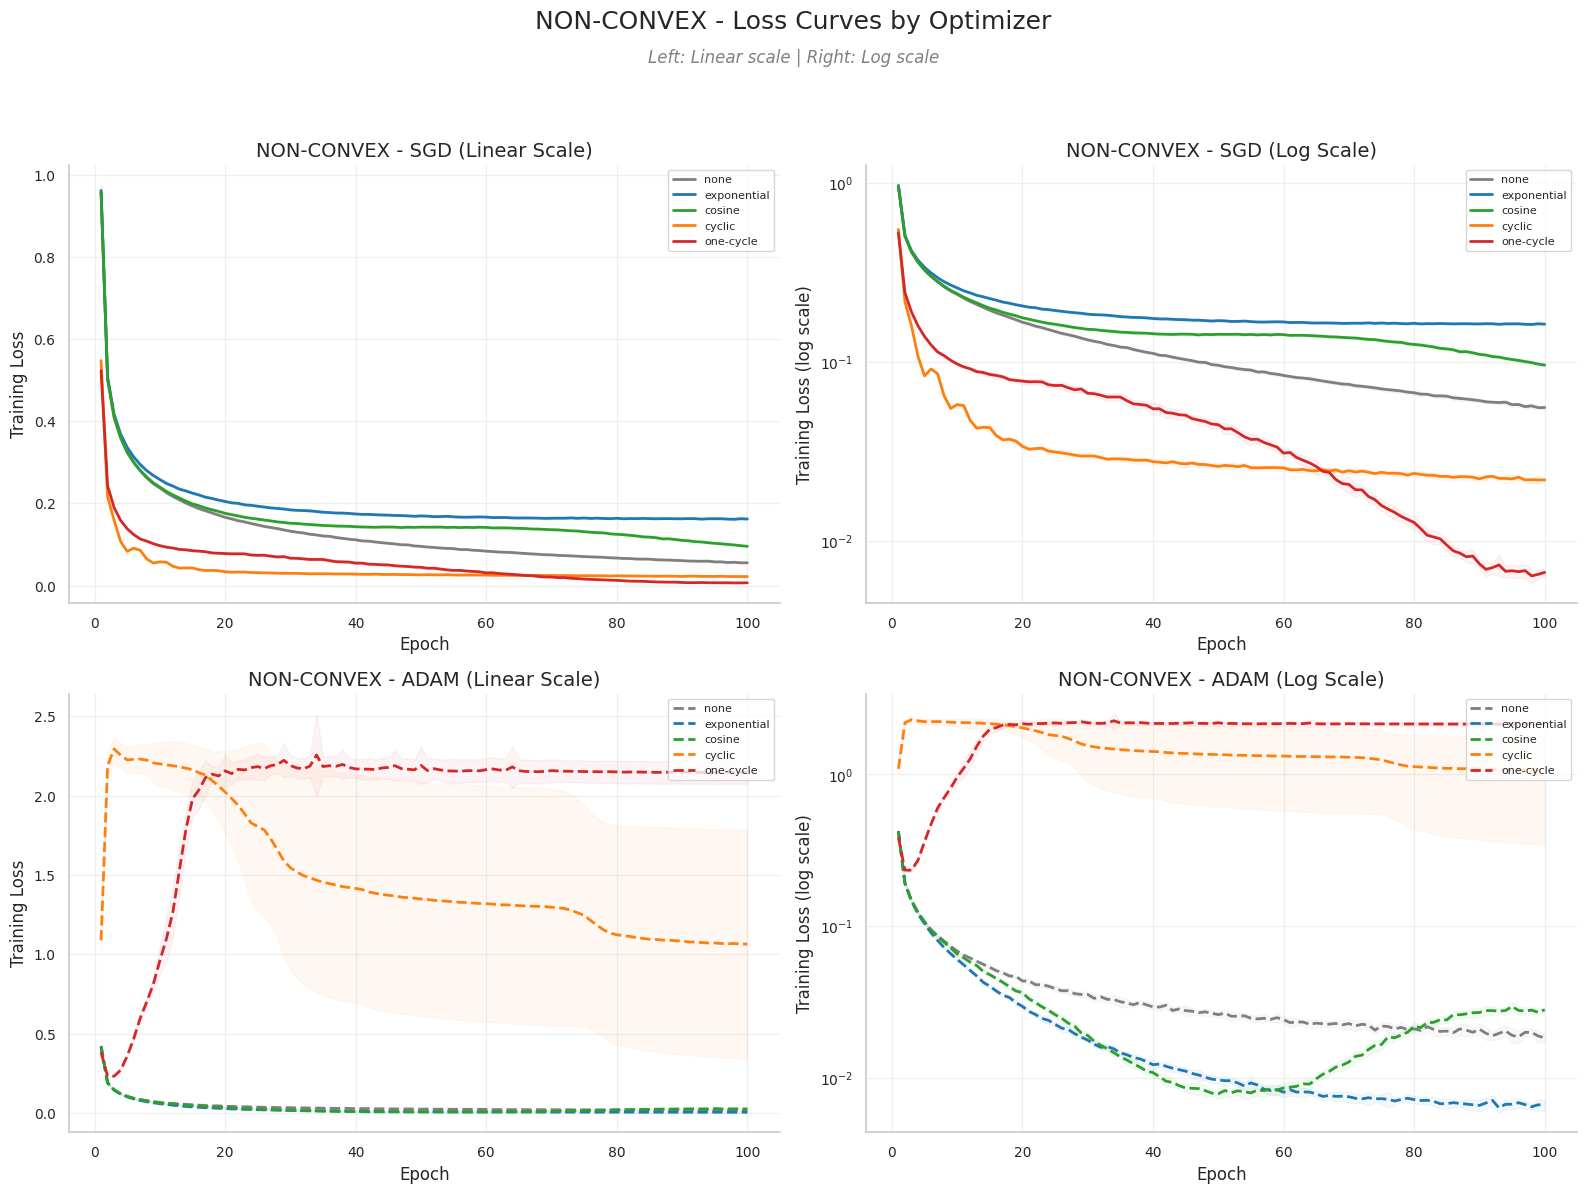

[viz] Saved: ../reports/figures/non-convex_level3_seed_variance.png


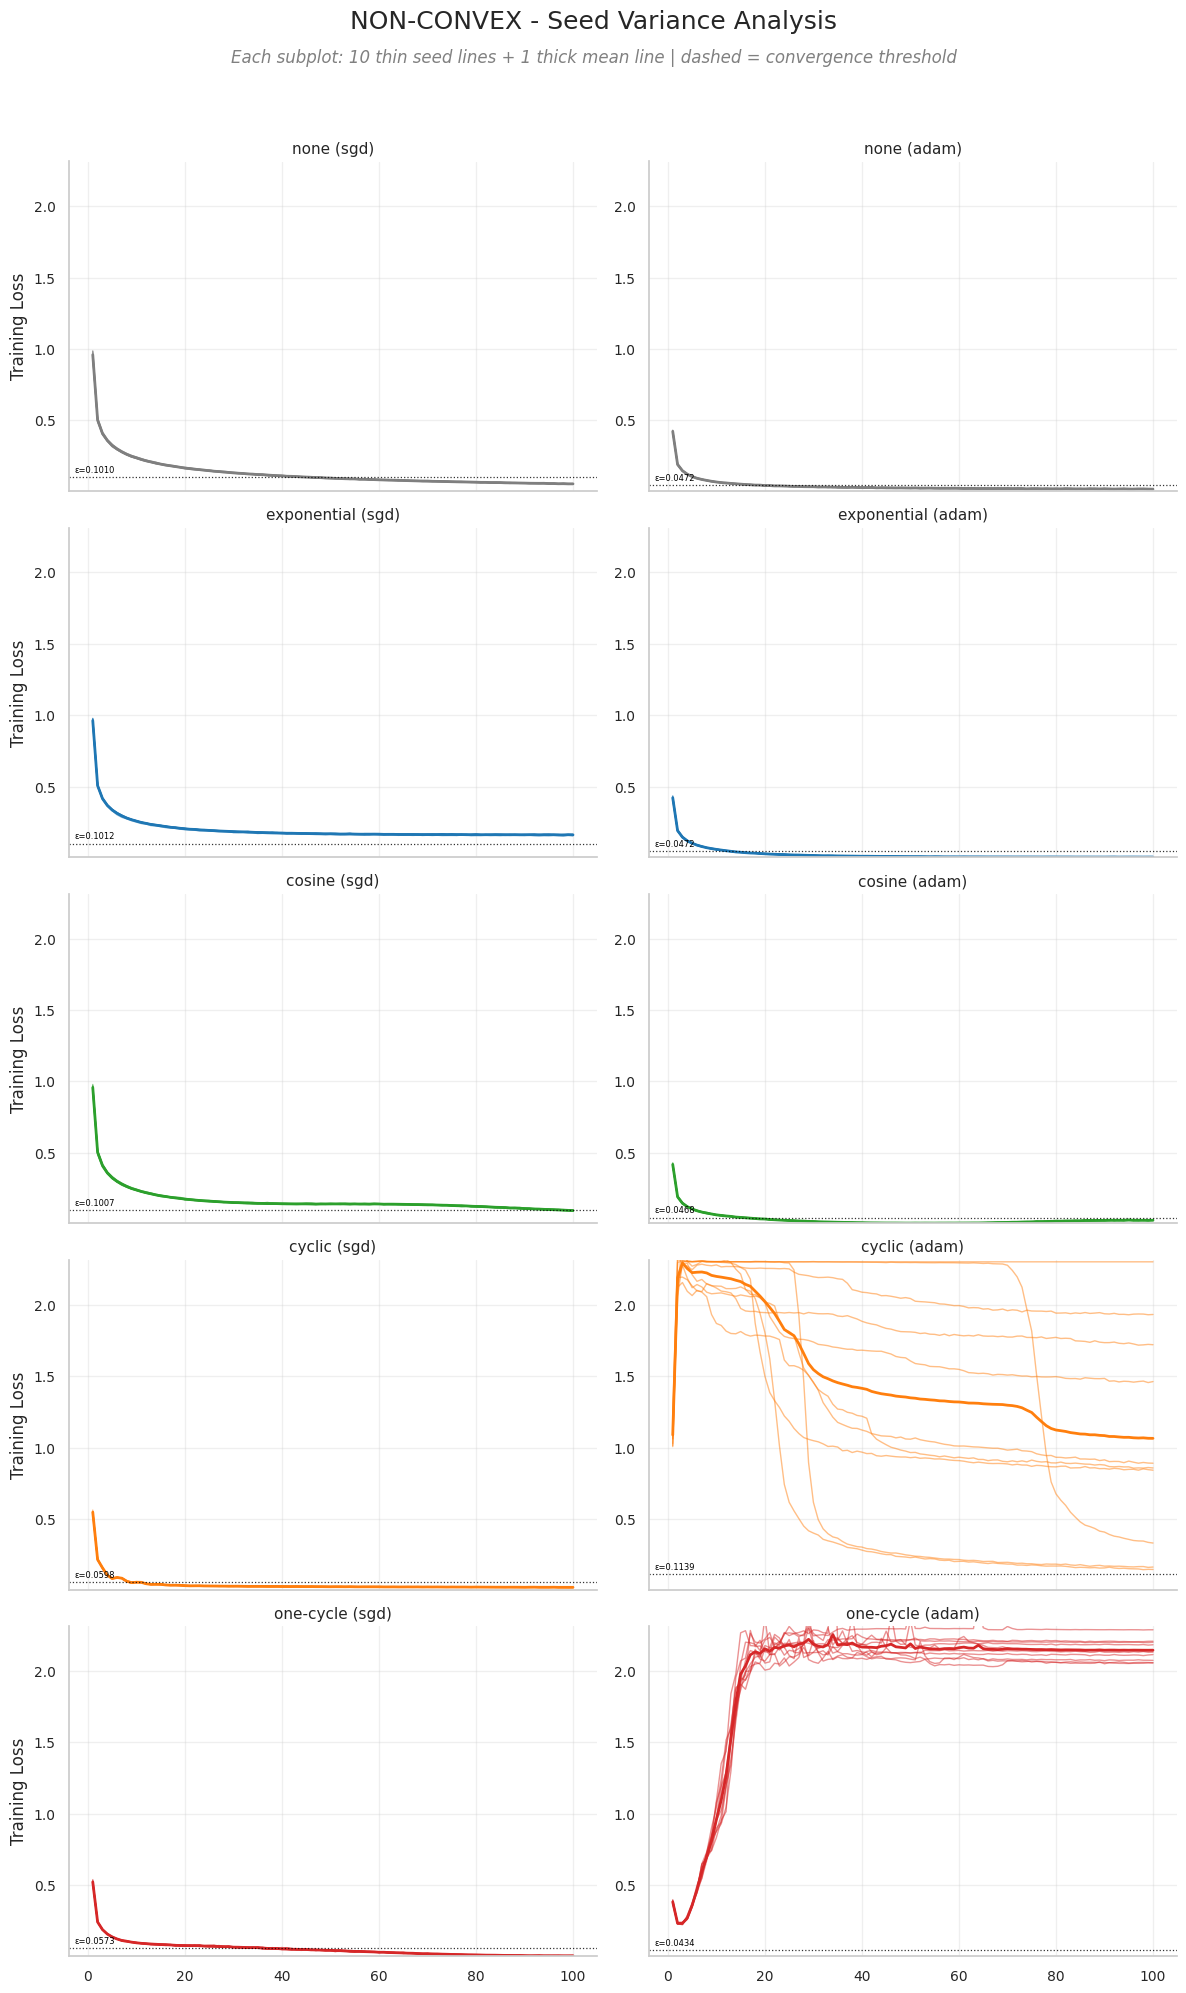

[viz] Saved: ../reports/figures/non-convex_level4_final_performance.png


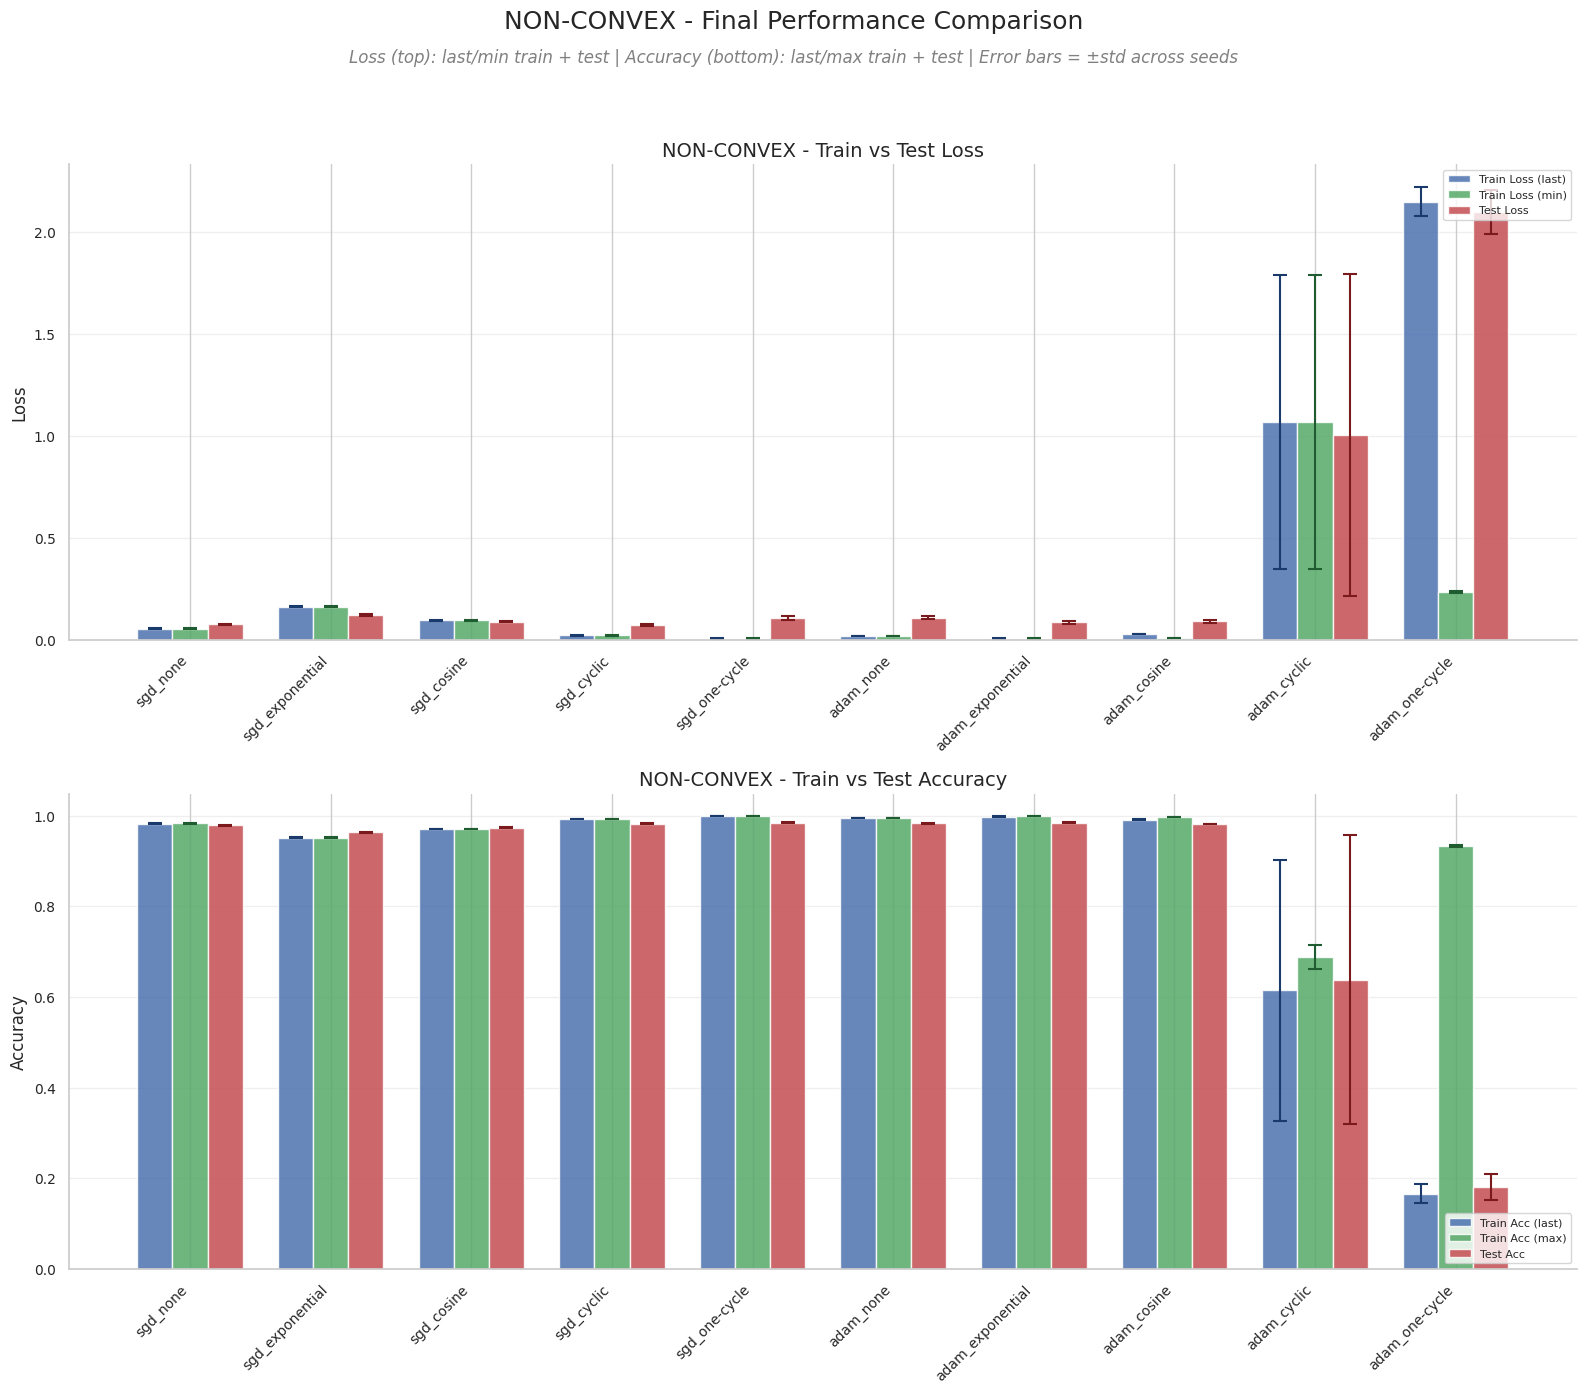

[viz] Saved: ../reports/figures/non-convex_analytical_a_loss_lr_dual.png


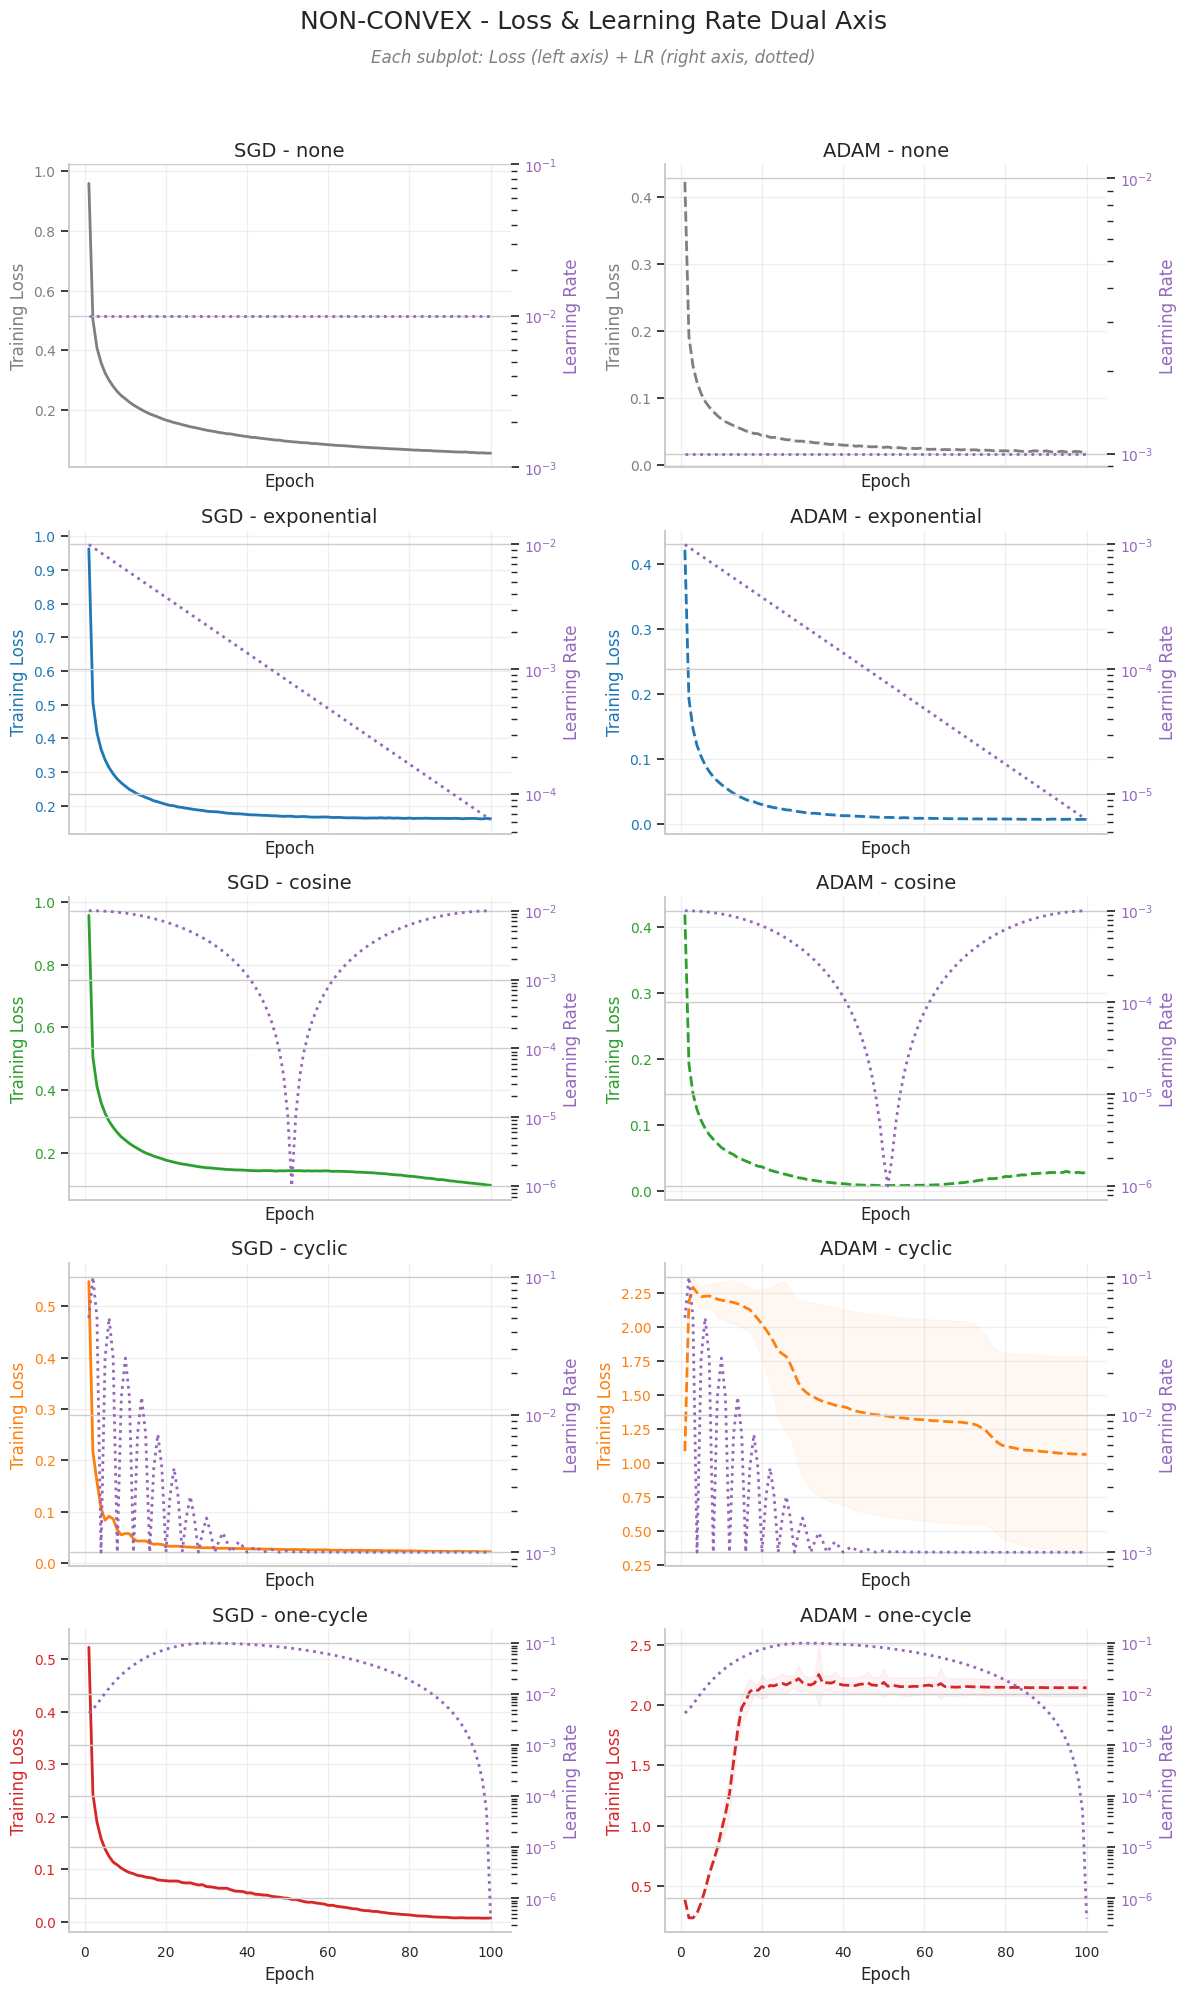

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_ett.png


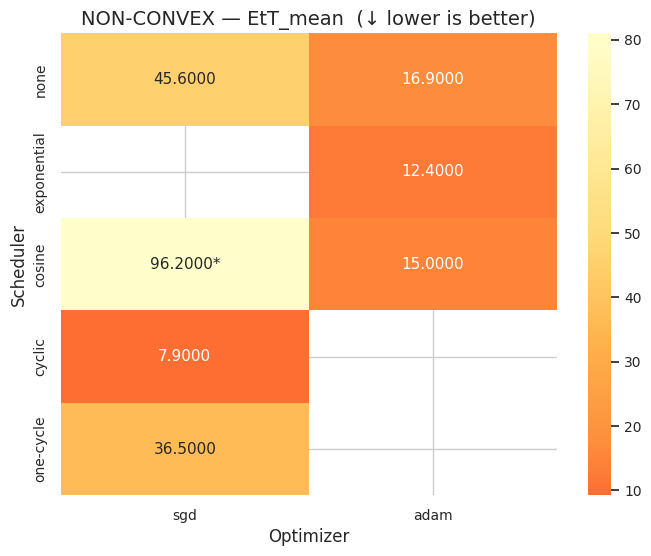

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_ett_median.png


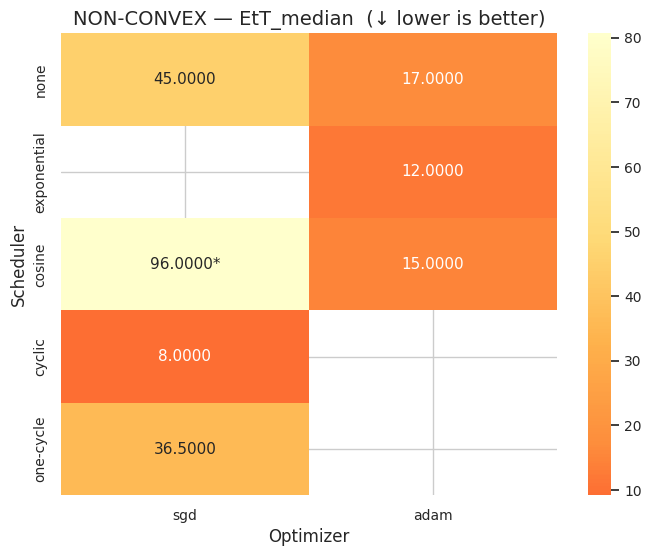

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_aul_norm.png


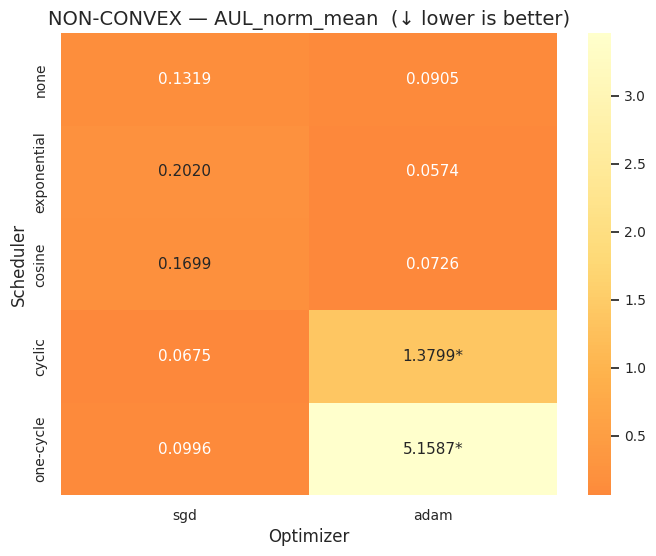

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_rho_hat.png


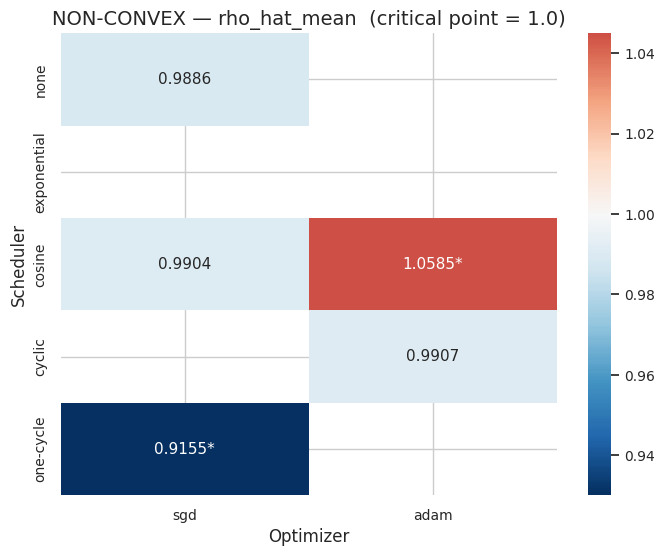

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_cv_final.png


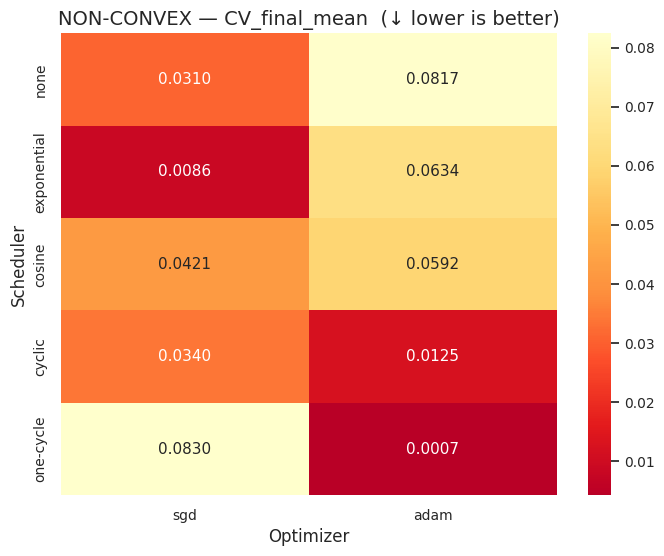

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_si.png


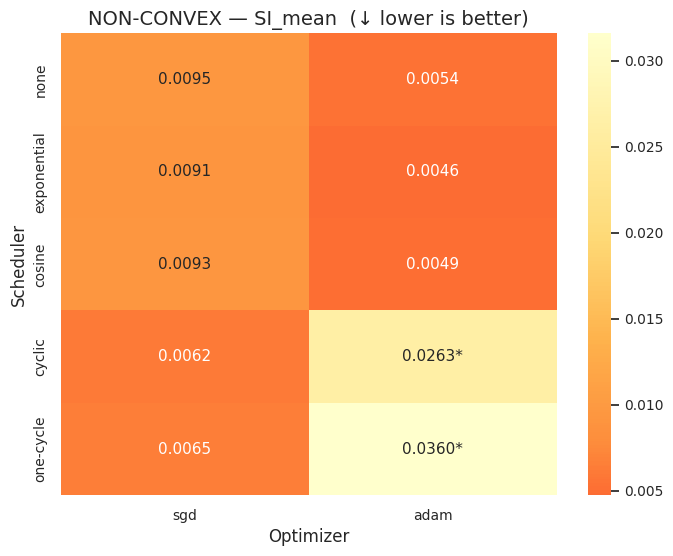

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_test_accuracy.png


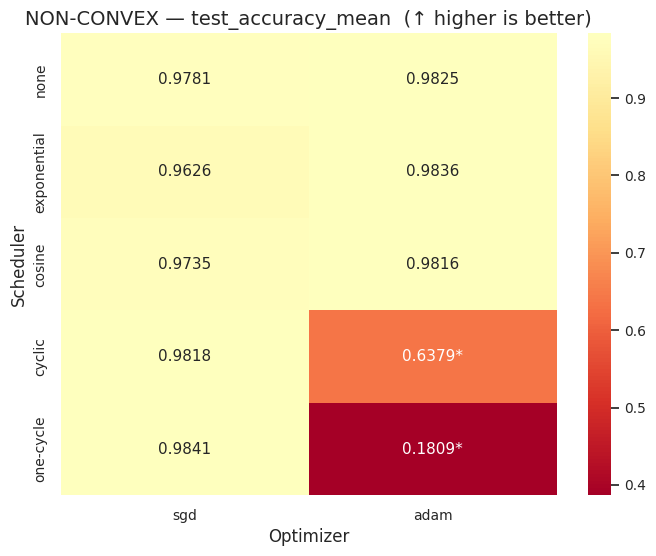

[viz] Saved: ../reports/figures/non-convex_analytical_b_heatmap_test_loss.png


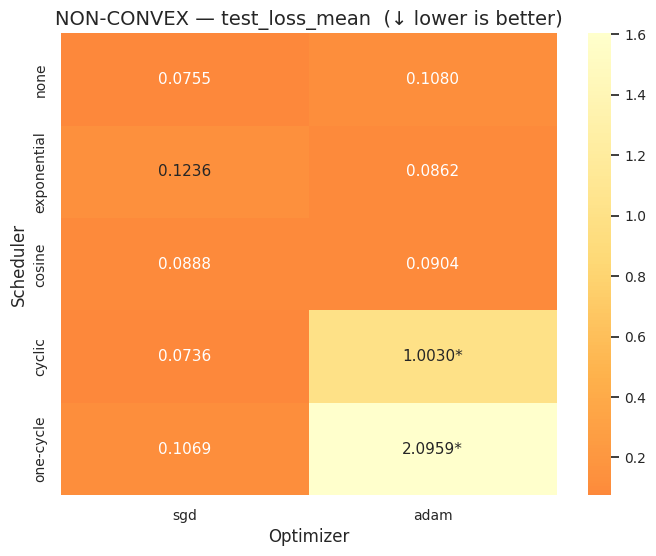

[viz] All plots saved for: non-convex


Saved 6 plot files:
  - ../reports/figures/non-convex_level1_global_comparison.png
  - ../reports/figures/non-convex_level2_by_optimizer.png
  - ../reports/figures/non-convex_level3_seed_variance.png
  - ../reports/figures/non-convex_level4_final_performance.png
  - ../reports/figures/non-convex_analytical_a_loss_lr_dual.png
  - ['../reports/figures/non-convex_analytical_b_heatmap_ett.png', '../reports/figures/non-convex_analytical_b_heatmap_ett_median.png', '../reports/figures/non-convex_analytical_b_heatmap_aul_norm.png', '../reports/figures/non-convex_analytical_b_heatmap_rho_hat.png', '../reports/figures/non-convex_analytical_b_heatmap_cv_final.png', '../reports/figures/non-convex_analytical_b_heatmap_si.png', '../reports/figures/non-convex_analytical_b_heatmap_test_accuracy.png', '../reports/figures/non-convex_analytical_b_heatmap_test_loss.png']


In [11]:

# Generate all plots for both problem types
for problem_type in ["convex", "non-convex"]:
    print(f"\n{'='*60}")
    print(f"Generating plots for: {problem_type.upper()}")
    print('='*60)
    
    # Get aggregated metrics
    aggregated = convergence_results[problem_type]["aggregated"]
    
    # Get results for this problem type
    results_by_problem = results[problem_type]
    
    # Compute L_star if available (for convex problems)
    L_star_global = convergence_results[problem_type]["L_star"]
    L0_global = convergence_results[problem_type].get("L0")
    e_target_levels = (
        CONVEX_E_TARGET_LEVELS if problem_type == "convex" else NONCONVEX_E_TARGET_LEVELS
    )
    print(f"L_star = {L_star_global:.6f}, L0 = {L0_global:.6f}")
    print(f"E_target levels: {e_target_levels}")
    
    # Generate all plots
    saved_files = plot_all(
        results_by_problem=results_by_problem,
        aggregated=aggregated,
        problem_type=problem_type,
        L_star_global=L_star_global,
        L0=L0_global,
        e_target_levels=e_target_levels,
        save_dir=figures_dir,
        show=True,  # Set to True to display plots
    )
    
    print(f"Saved {len(saved_files)} plot files:")
    for f in saved_files:
        print(f"  - {f}")

## 6b. Convergence Velocity (Epochs-to-Target Boxplots)

For each E_target level, visualize the distribution of epochs required
to reach the target loss across all configurations and seeds.

In [ ]:
for problem_type in ["convex", "non-convex"]:
    levels = CONVEX_E_TARGET_LEVELS if problem_type == "convex" else NONCONVEX_E_TARGET_LEVELS
    for level_name, eps in levels.items():
        df = e_target_results[problem_type][level_name]
        if df.empty:
            continue
        L_target = df["_L_target"].iloc[0]
        max_epochs = config.experiments[problem_type].epochs or config.epochs
        save_path = figures_dir / f"{problem_type}_{level_name}_boxplot.png"

        fig = plot_convergence_boxplot(
            df, problem_type, L_target, max_epochs,
            save_path=save_path,
            show=True,
        )


In [ ]:
for problem_type in ["convex", "non-convex"]:
    levels = CONVEX_E_TARGET_LEVELS if problem_type == "convex" else NONCONVEX_E_TARGET_LEVELS
    for level_name, eps in levels.items():
        df = e_target_results[problem_type][level_name]
        if df.empty:
            continue
        L_target = df["_L_target"].iloc[0]
        max_epochs = config.experiments[problem_type].epochs or config.epochs
        save_path = figures_dir / f"{problem_type}_{level_name}_boxplot.png"

        fig = plot_convergence_boxplot(
            df, problem_type, L_target, max_epochs,
            save_path=save_path,
            show=True,
        )


## 7. Summary & Key Findings

### Best Configuration per Problem Type

In [16]:
for problem_type in ["convex", "non-convex"]:
    agg = convergence_results[problem_type]["aggregated"]
    
    # Find best by accuracy
    best_acc_key = max(agg.keys(), key=lambda k: agg[k].get("test_accuracy_mean", 0))
    best_acc = agg[best_acc_key]
    
    # Find fastest convergence (lowest EtT)
    best_ett_key = min(agg.keys(), key=lambda k: agg[k].get("EtT_mean", float("inf")))
    best_ett = agg[best_ett_key]
    
    # Find most stable (lowest CV)
    best_stable_key = min(agg.keys(), key=lambda k: agg[k].get("CV_final_mean", float("inf")))
    best_stable = agg[best_stable_key]
    
    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Summary")
    print(f"{'='*60}")
    print(f"Best accuracy:     {best_acc['optimizer']} + {best_acc['scheduler']} → {best_acc['test_accuracy_mean']:.4f} ± {best_acc['test_accuracy_std']:.4f}")
    print(f"Fastest converge:  {best_ett['optimizer']} + {best_ett['scheduler']} → EtT={best_ett['EtT_mean']:.1f} ± {best_ett['EtT_std']:.1f}")
    print(f"Most stable:       {best_stable['optimizer']} + {best_stable['scheduler']} → CV={best_stable['CV_final_mean']:.6f}")


CONVEX - Summary
Best accuracy:     sgd + one-cycle → 0.9754 ± 0.0102
Fastest converge:  adam + cyclic → EtT=2.1 ± 0.3
Most stable:       sgd + one-cycle → CV=0.000348

NON-CONVEX - Summary
Best accuracy:     sgd + one-cycle → 0.9841 ± 0.0012
Fastest converge:  sgd + cyclic → EtT=7.9 ± 0.3
Most stable:       adam + one-cycle → CV=0.000730


## 8. Save and Load Results

### Save Convergence metrics

In [17]:
# Export results to CSV for further analysis
for problem_type in ["convex", "non-convex"]:
    metrics_list = convergence_results[problem_type]["per_run"]
    df = pd.DataFrame(metrics_list)
    csv_path = results_dir / f"{problem_type}_metrics.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path} ({len(df)} rows)")

Saved: ../results/convex_metrics.csv (18 rows)
Saved: ../results/non-convex_metrics.csv (18 rows)


### Save results dict

In [ ]:
def save_results(results: dict, save_dir: str | Path = Path("../results"), filename: str = "results.pkl") -> Path:
    """
    Serialize results dict to disk using pickle (no compression, no conversion).

    Args:
        results:  The dict to save.
        save_dir: Directory where the file will be written (created if missing).
        filename: Output filename (default: results.pkl).

    Returns:
        Path of the saved file.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    output_path = save_dir / filename
    with open(output_path, "wb") as f:
        pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
    return output_path

# Salvataggio
save_results(results, save_dir=results_dir)


PosixPath('../results/results.pkl')

### Load results dict

In [6]:
def load_results(save_dir: str | Path = Path("../results"), filename: str = "results.pkl") -> dict:
    """
    Load results dict from disk.

    Args:
        save_dir: Directory containing the file.
        filename: File to load (default: results.pkl).

    Returns:
        The deserialized dict.

    Raises:
        FileNotFoundError: If the file does not exist.
    """
    path = Path(save_dir) / filename
    if not path.exists():
        raise FileNotFoundError(f"Results file not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)
    

# Caricamento
results = load_results(save_dir=results_dir)

## Load Result from MlFLow

In [6]:
results = load_results_from_mlflow(
    experiment_name="scheduler_comparison_v3",
    tracking_uri="../mlruns",  # o URI remoto
)

/home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/.venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
